# 06: Binary Classification

This notebook trains and evaluates multiple classifiers on the binary intrusion detection task — predicting whether network traffic is normal (0) or an attack (1).

Four models are compared: Logistic Regression (baseline), Random Forest, XGBoost, and a Multi-Layer Perceptron (MLP). Each model is evaluated using stratified cross-validation on the training set to measure generalisation performance before any test data is touched. The best model is then evaluated on the held-out test set, and a series of post-hoc analyses — threshold optimisation, explainability, calibration, and benchmarking — are performed to understand and validate the final classifier.

## 6.1: Import Libraries

This section imports all third-party libraries and configures global display settings. Libraries are grouped by purpose: data manipulation (pandas, numpy), visualisation (matplotlib, seaborn), machine learning (scikit-learn, xgboost), and explainability (shap, lime). Display options are set once here to avoid repeating them throughout the notebook.

In [1]:
import warnings
# Suppress tqdm's IProgress warning when ipywidgets is not installed in the Jupyter environment.
warnings.filterwarnings('ignore', message='IProgress not found')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
import timeit
import joblib
import os
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.neural_network import MLPClassifier
from lime import lime_tabular

# Prevent truncation of long column values in displayed DataFrames.
pd.set_option('display.max_colwidth', None)

# Set a white grid background for all plots.
sns.set_style('whitegrid')

## 6.2: Load Data

This section loads the engineered train and test splits produced by `05_feature_engineering.ipynb`. Both files contain the full feature set plus two target columns (`Label` and `attack_cat`). Printing the shapes immediately after loading confirms that the expected number of rows and columns are present before any further processing.

In [2]:
# Load the engineered train and test splits produced by 05_feature_engineering.ipynb.
# Both files contain the same feature columns plus the two target columns (Label, attack_cat).
train = pd.read_csv('../data/engineered/train.csv', low_memory=False)
test = pd.read_csv('../data/engineered/test.csv', low_memory=False)

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')

Train shape: (280268, 49)
Test shape:  (404894, 49)


## 6.3: Prepare Features and Target

This section separates the feature matrix from the target labels for both the training and test sets. The `attack_cat` column is excluded here because this notebook only trains the binary classifier; it will serve as the target in `07_modelling_classifier.ipynb`. Printing the class distributions confirms the expected 3:1 normal-to-attack ratio in the resampled training set and the natural (~87%/~13%) split in the test set, which preserves the realistic deployment distribution.

In [3]:
# Both target columns are dropped to form the feature matrix.
# attack_cat is excluded here because this notebook only trains the binary classifier.
# It will be the target in 07_modelling_classifier.ipynb instead.
DROP_COLUMNS = ['Label', 'attack_cat']

features_train = train.drop(columns=DROP_COLUMNS)

# 0 = normal, 1 = attack
labels_train = train['Label']

features_test = test.drop(columns=DROP_COLUMNS)
labels_test = test['Label']

# Print class distributions to confirm resampling (train) and natural split (test).
print(f'features_train: {features_train.shape}')
print('labels_train distribution:')
print(labels_train.value_counts(normalize=True).rename({0: 'normal', 1: 'attack'}).to_frame('proportion').round(3))

print(f'\nfeatures_test: {features_test.shape}')
print('labels_test distribution:')
print(labels_test.value_counts(normalize=True).rename({0: 'normal', 1: 'attack'}).to_frame('proportion').round(3))

features_train: (280268, 47)
labels_train distribution:
        proportion
Label             
normal        0.75
attack        0.25

features_test: (404894, 47)
labels_test distribution:
        proportion
Label             
normal       0.956
attack       0.044


## 6.4: Cross-Validation Setup

All models are evaluated using 5-fold stratified cross-validation on the training set. Stratification ensures each fold preserves the class ratio, which matters here because the resampled training set has a fixed 3:1 normal-to-attack ratio. Three scoring metrics are collected per fold — accuracy, Receiver Operating Characteristic Area Under the Curve (ROC-AUC), and macro F1 — providing complementary views of model performance. The cross-validation results dictionary accumulates per-model fold scores for comparison in section 6.9.

In [4]:
# StratifiedKFold preserves the class ratio in every fold, which matters here because
# the resampled training set has a fixed 3:1 normal:attack ratio.
# shuffle=True randomises the fold assignment before splitting.
STRATIFIED_KFOLD = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics collected per fold:
# accuracy — overall correct predictions
# roc_auc  — area under the ROC curve; measures ranking quality regardless of threshold
# f1_macro — unweighted average F1 across both classes; treats Normal and Attack equally
SCORING = ['accuracy', 'roc_auc', 'f1_macro']

# Dictionary to accumulate cross-validation results for each model so they can be compared in section 6.9.
cross_validation_results = {}

## 6.5: Logistic Regression

Logistic Regression is used as the baseline model. It fits a linear decision boundary and produces calibrated probability scores, making ROC-AUC straightforward to interpret. Its simplicity makes it a useful reference point: any non-linear model should substantially outperform it to justify the additional complexity. The out-of-fold (OOF) classification report provides a per-class breakdown of precision, recall, and F1 without touching the held-out test set.

In [5]:
# max_iter=1000 — default 100 is often too low for standardised data with many features;
# increasing it ensures the solver converges rather than stopping early.
logistic_regression = LogisticRegression(max_iter=1000, random_state=42)

# cross_validate runs the full fit-predict cycle for each cross-validation fold and returns per-fold scores.
cross_validation_results['Logistic Regression'] = cross_validate(
    logistic_regression, features_train, labels_train,
    cv=STRATIFIED_KFOLD, scoring=SCORING, n_jobs=-1,
)

print('=== Logistic Regression — Cross-Validation Scores ===')
for metric in SCORING:
    scores = cross_validation_results['Logistic Regression'][f'test_{metric}']

    # Report mean ± std across folds — std indicates how stable the score is across folds.
    print(f'{metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

# cross_val_predict returns one prediction per training sample, each made by a fold
# that did not include that sample during training (out-of-fold predictions).
# This gives a fair per-class breakdown without touching the held-out test set.
logistic_regression_out_of_fold = cross_val_predict(
    logistic_regression, features_train, labels_train,
    cv=STRATIFIED_KFOLD, n_jobs=-1,
)

print('\n=== Logistic Regression — Classification Report (Cross-Validation Out-of-Fold) ===')
print(classification_report(labels_train, logistic_regression_out_of_fold, target_names=['Normal', 'Attack'], digits=4))

=== Logistic Regression — Cross-Validation Scores ===
accuracy    : 0.9879 ± 0.0007
roc_auc     : 0.9977 ± 0.0001
f1_macro    : 0.9840 ± 0.0009

=== Logistic Regression — Classification Report (Cross-Validation Out-of-Fold) ===
              precision    recall  f1-score   support

      Normal     0.9984    0.9854    0.9919    210201
      Attack     0.9578    0.9953    0.9762     70067

    accuracy                         0.9879    280268
   macro avg     0.9781    0.9903    0.9840    280268
weighted avg     0.9883    0.9879    0.9879    280268



## 6.6: Random Forest

Random Forest is an ensemble of decision trees, each trained on a bootstrap sample of rows and a random subset of features. This decorrelates the trees and reduces overfitting compared to a single decision tree. It handles non-linear relationships well and provides native feature importances via mean decrease in impurity (MDI). The out-of-fold (OOF) classification report shows how the ensemble performs on samples it was not trained on within each cross-validation fold.

In [6]:
# n_estimators=100 — number of trees in the forest; more trees reduce variance but increase
# training time. 100 is a reasonable starting point for this dataset size.
# Each tree is trained on a bootstrap sample of rows and a random subset of features,
# which decorrelates the trees and reduces overfitting compared to a single decision tree.
random_forest = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Run cross-validation and store per-fold scores.
cross_validation_results['Random Forest'] = cross_validate(
    random_forest, features_train, labels_train,
    cv=STRATIFIED_KFOLD, scoring=SCORING, n_jobs=-1,
)

print('=== Random Forest — Cross-Validation Scores ===')
for metric in SCORING:
    scores = cross_validation_results['Random Forest'][f'test_{metric}']
    print(f'{metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

# Out-of-fold predictions — each sample is predicted by trees trained without it.
random_forest_out_of_fold = cross_val_predict(
    random_forest, features_train, labels_train,
    cv=STRATIFIED_KFOLD, n_jobs=-1,
)

print('\n=== Random Forest — Classification Report (Cross-Validation Out-of-Fold) ===')
print(classification_report(labels_train, random_forest_out_of_fold, target_names=['Normal', 'Attack'], digits=4))

=== Random Forest — Cross-Validation Scores ===
accuracy    : 0.9890 ± 0.0003
roc_auc     : 0.9988 ± 0.0001
f1_macro    : 0.9855 ± 0.0004

=== Random Forest — Classification Report (Cross-Validation Out-of-Fold) ===
              precision    recall  f1-score   support

      Normal     0.9982    0.9871    0.9926    210201
      Attack     0.9626    0.9947    0.9784     70067

    accuracy                         0.9890    280268
   macro avg     0.9804    0.9909    0.9855    280268
weighted avg     0.9893    0.9890    0.9891    280268



## 6.7: XGBoost

XGBoost is a gradient-boosted tree ensemble that iteratively corrects the residual errors of the previous trees. It consistently performs well on structured and tabular data and typically outperforms other models on this type of task. The out-of-fold (OOF) classification report provides a fair per-class evaluation without touching the held-out test set. Expect XGBoost to score higher than both Logistic Regression and Random Forest on ROC-AUC.

In [7]:
# XGBoost builds trees sequentially; each new tree corrects the residual errors of the
# ensemble so far.
# Key parameters:
# learning_rate=0.1     — shrinks each tree's contribution; lower values require more trees
#                         but generalise better. Paired with n_estimators=100 as a starting point.
# max_depth=6           — maximum depth per tree; deeper trees capture more complex patterns
#                         but are more prone to overfitting.
# eval_metric='logloss' — loss function used internally during training (binary cross-entropy).
# verbosity=0           — suppress training output to keep the notebook output clean.
xgboost_classifier = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0,
)

# Run cross-validation and store per-fold scores.
cross_validation_results['XGBoost'] = cross_validate(
    xgboost_classifier, features_train, labels_train,
    cv=STRATIFIED_KFOLD, scoring=SCORING, n_jobs=-1,
)

print('=== XGBoost — Cross-Validation Scores ===')
for metric in SCORING:
    scores = cross_validation_results['XGBoost'][f'test_{metric}']
    print(f'{metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

# Out-of-fold predictions for classification report.
xgboost_out_of_fold = cross_val_predict(
    xgboost_classifier, features_train, labels_train,
    cv=STRATIFIED_KFOLD, n_jobs=-1,
)

print('\n=== XGBoost — Classification Report (Cross-Validation Out-of-Fold) ===')
print(classification_report(labels_train, xgboost_out_of_fold, target_names=['Normal', 'Attack'], digits=4))

=== XGBoost — Cross-Validation Scores ===
accuracy    : 0.9893 ± 0.0005
roc_auc     : 0.9989 ± 0.0001
f1_macro    : 0.9859 ± 0.0007

=== XGBoost — Classification Report (Cross-Validation Out-of-Fold) ===
              precision    recall  f1-score   support

      Normal     0.9999    0.9858    0.9928    210201
      Attack     0.9591    0.9998    0.9790     70067

    accuracy                         0.9893    280268
   macro avg     0.9795    0.9928    0.9859    280268
weighted avg     0.9897    0.9893    0.9894    280268



## 6.8: Multi-Layer Perceptron (Neural Network)

A Multi-Layer Perceptron (MLP) with two hidden layers learns by passing inputs forward through layers of neurons, computing a loss, then adjusting weights via backpropagation. With the large resampled training set the MLP has sufficient data to learn complex non-linear patterns, though it is slower to train than tree-based ensembles. Early stopping prevents overfitting without manual epoch tuning. The out-of-fold (OOF) classification report provides a fair per-class evaluation.

In [8]:
# An MLP learns by passing inputs forward through layers of neurons (forward pass),
# computing a loss, then adjusting weights via backpropagation.
# Key parameters:
# hidden_layer_sizes=(128, 64) — two hidden layers with 128 and 64 neurons respectively;
#                                the network narrows as it abstracts features.
# activation='relu'            — Rectified Linear Unit; avoids the vanishing gradient
#                                problem common with sigmoid/tanh in deep networks.
# max_iter=200                 — maximum number of training epochs.
# early_stopping=True          — halts training when validation loss stops improving,
#                                preventing overfitting without manual epoch tuning.
# validation_fraction=0.1      — 10% of training data held back internally to monitor
#                                the early stopping criterion.
multilayer_perceptron = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
)

# Run cross-validation and store per-fold scores.
cross_validation_results['MLP'] = cross_validate(
    multilayer_perceptron, features_train, labels_train,
    cv=STRATIFIED_KFOLD, scoring=SCORING, n_jobs=-1,
)

print('=== MLP — Cross-Validation Scores ===')
for metric in SCORING:
    scores = cross_validation_results['MLP'][f'test_{metric}']
    print(f'{metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

# Out-of-fold predictions for classification report.
multilayer_perceptron_out_of_fold = cross_val_predict(
    multilayer_perceptron, features_train, labels_train,
    cv=STRATIFIED_KFOLD, n_jobs=-1,
)

print('\n=== MLP — Classification Report (Cross-Validation Out-of-Fold) ===')
print(classification_report(labels_train, multilayer_perceptron_out_of_fold, target_names=['Normal', 'Attack'], digits=4))

=== MLP — Cross-Validation Scores ===
accuracy    : 0.9892 ± 0.0005
roc_auc     : 0.9985 ± 0.0002
f1_macro    : 0.9858 ± 0.0006

=== MLP — Classification Report (Cross-Validation Out-of-Fold) ===
              precision    recall  f1-score   support

      Normal     0.9999    0.9857    0.9928    210201
      Attack     0.9589    0.9996    0.9789     70067

    accuracy                         0.9892    280268
   macro avg     0.9794    0.9927    0.9858    280268
weighted avg     0.9896    0.9892    0.9893    280268



## 6.9: Model Comparison

This section aggregates the mean cross-validation scores from all four models into a single ranked table and bar chart. Sorting by ROC-AUC provides a threshold-independent ranking of each model's discriminative ability. This comparison determines which model proceeds to test-set evaluation in section 6.11. Expect XGBoost to rank first, with Random Forest and MLP trailing Logistic Regression by a visible margin.

In [9]:
# Build a summary DataFrame of mean cross-validation scores for each model.
# Sorting by ROC-AUC makes it easy to rank models — AUC is threshold-independent
# and a robust measure of overall discriminative ability.
rows = []
for name, results in cross_validation_results.items():
    rows.append({
        'Model': name,
        'Accuracy': results['test_accuracy'].mean(),
        'ROC-AUC': results['test_roc_auc'].mean(),
        'F1 (macro)': results['test_f1_macro'].mean(),
    })

comparison = pd.DataFrame(rows).set_index('Model').round(4)
comparison = comparison.sort_values('ROC-AUC', ascending=False)

print('=== Cross-Validation Score Comparison (Mean Across 5 Folds) ===')
print(comparison)

=== Cross-Validation Score Comparison (Mean Across 5 Folds) ===
                     Accuracy  ROC-AUC  F1 (macro)
Model                                             
XGBoost                0.9893   0.9989      0.9859
Random Forest          0.9890   0.9988      0.9855
MLP                    0.9892   0.9985      0.9858
Logistic Regression    0.9879   0.9977      0.9840


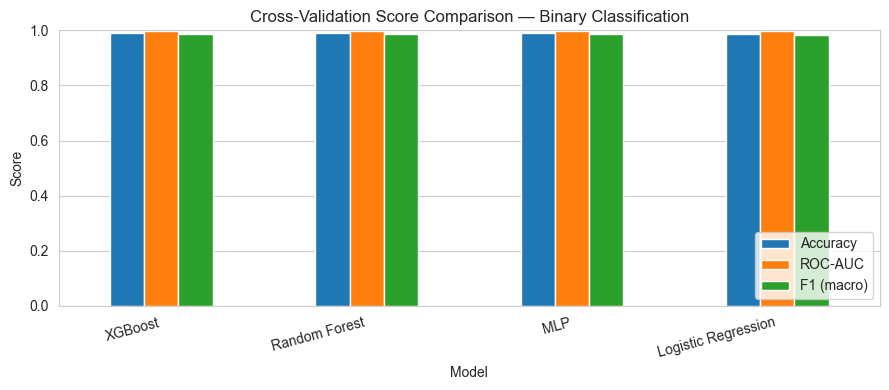

In [10]:
# Bar chart of mean cross-validation scores — visually highlights differences between models
# across all three metrics at a glance.
figure, plot_ax = plt.subplots(figsize=(9, 4))
comparison.plot(kind='bar', ax=plot_ax)
plot_ax.set_title('Cross-Validation Score Comparison — Binary Classification')
plot_ax.set_ylabel('Score')
plot_ax.set_ylim(0, 1)
plot_ax.set_xticklabels(comparison.index, rotation=15, ha='right')
plot_ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 6.9.1: Cross-Validation Fold Score Distribution

Box plots expose the per-fold score distribution for each model. Mean ± standard deviation summaries can hide skewed or bimodal fold results — the box plot makes the spread and outliers explicit. A narrow interquartile range indicates a stable, consistent model across different data partitions. Wide boxes or outlier folds suggest that the model's performance is sensitive to which samples end up in each fold.

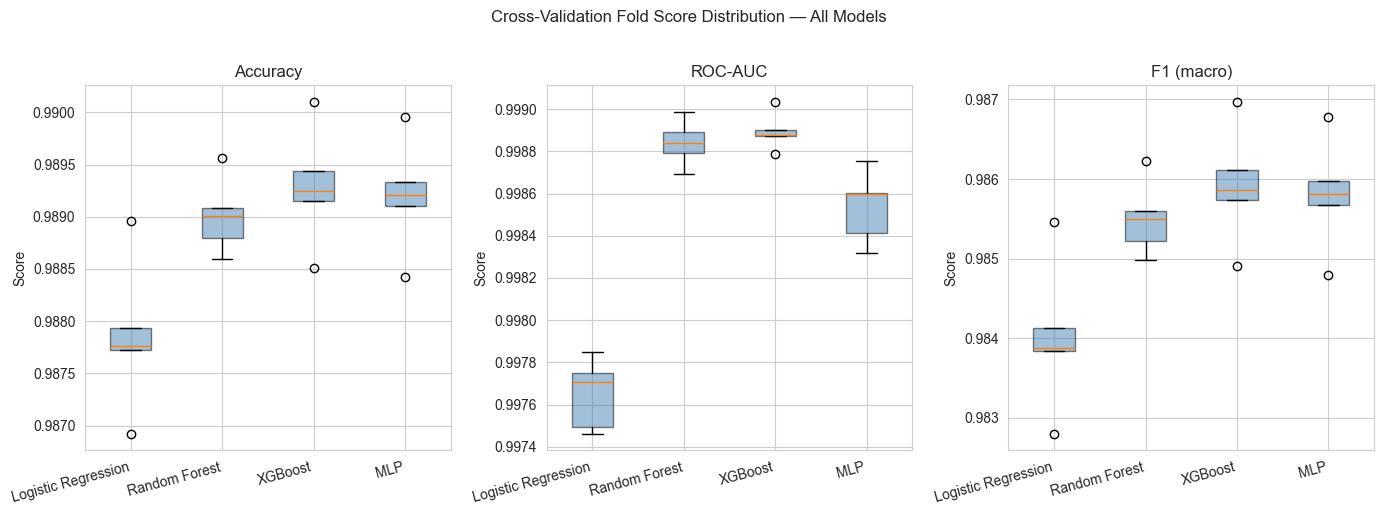

In [11]:
# Box plot of per-fold cross-validation scores for all models across all three metrics.
# Each box shows the median, interquartile range, and outliers across the 5 folds.
figure, axes = plt.subplots(1, 3, figsize=(14, 5))
model_names_list = list(cross_validation_results.keys())

for ax, metric, title in zip(
    axes,
    ['test_accuracy', 'test_roc_auc', 'test_f1_macro'],
    ['Accuracy', 'ROC-AUC', 'F1 (macro)'],
):
    fold_scores = [cross_validation_results[m][metric] for m in model_names_list]
    ax.boxplot(fold_scores, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5))
    ax.set_title(title)
    ax.set_ylabel('Score')
    ax.set_xticks(range(1, len(model_names_list) + 1))
    ax.set_xticklabels(model_names_list, rotation=15, ha='right')

plt.suptitle('Cross-Validation Fold Score Distribution — All Models', y=1.02)
plt.tight_layout()
plt.show()

## 6.10: Feature Importance

This section computes and visualises feature importances from both Random Forest and XGBoost, fitted on the full training set rather than a single cross-validation fold. Random Forest importances use mean decrease in impurity (MDI) — the average reduction in node impurity a feature causes across all trees. XGBoost importances use gain — the average improvement in loss when a feature is used in a split. Comparing the two methods side-by-side reveals which features are consistently important and where the two approaches disagree. Section 6.10.1 further validates these rankings using permutation importance, which is unbiased toward high-cardinality features.

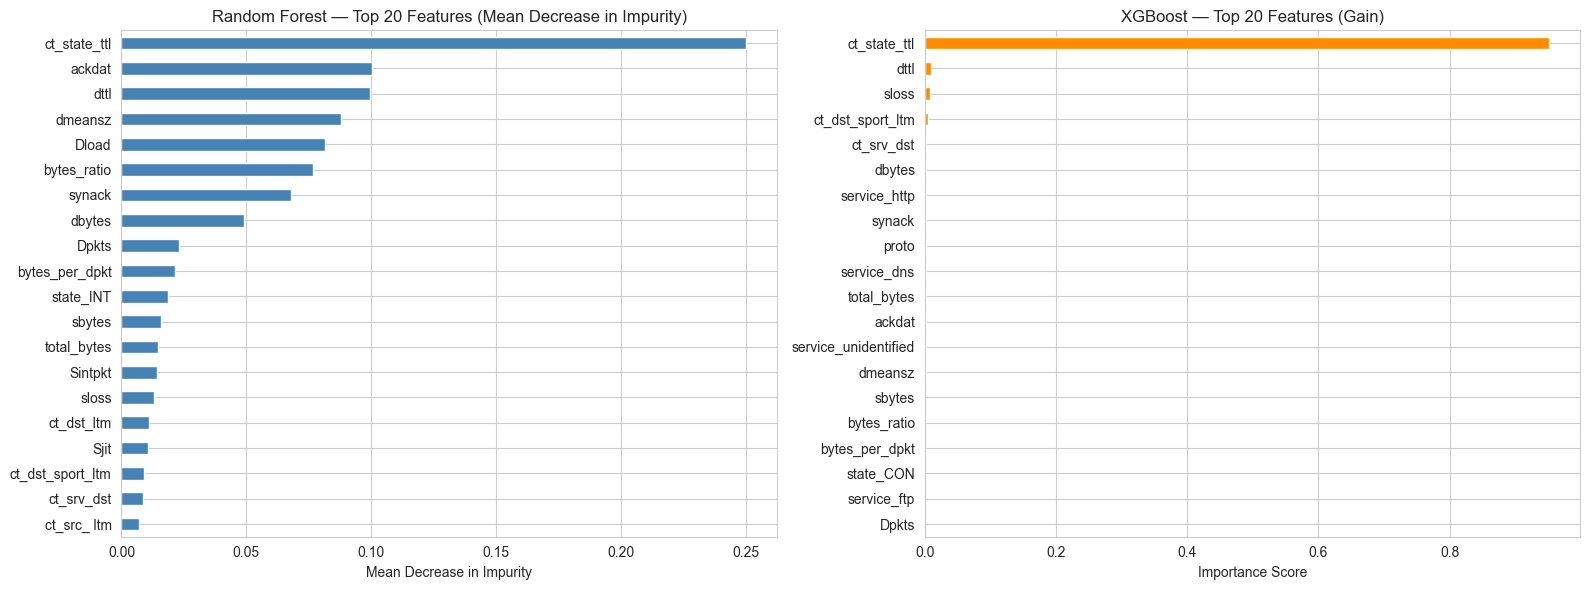

In [12]:
# Fit both models on the full training set (not just one cross-validation fold) so that importances
# are computed from a model that has seen all available training data.
# Note: random_forest and xgboost_classifier were instantiated in sections 6.6 and 6.7 respectively.
random_forest.fit(features_train, labels_train)
xgboost_classifier.fit(features_train, labels_train)

feature_names = features_train.columns

# Random Forest importance = mean decrease in impurity (Gini) across all trees.
# Higher values mean the feature caused larger reductions in node impurity on average.
random_forest_importance = pd.Series(
    random_forest.feature_importances_, index=feature_names
).sort_values(ascending=False)

# XGBoost importance = gain — average loss improvement when a feature is used for a split.
xgboost_importance = pd.Series(
    xgboost_classifier.feature_importances_, index=feature_names
).sort_values(ascending=False)

# Only show the top 20 to keep the chart readable.
TOP_N_FEATURES = 20

figure, subplot_axes = plt.subplots(1, 2, figsize=(16, 6))

random_forest_importance.head(TOP_N_FEATURES).plot(kind='barh', ax=subplot_axes[0], color='steelblue')
subplot_axes[0].set_title(f'Random Forest — Top {TOP_N_FEATURES} Features (Mean Decrease in Impurity)')
subplot_axes[0].set_xlabel('Mean Decrease in Impurity')
subplot_axes[0].invert_yaxis()  # Highest importance at the top

xgboost_importance.head(TOP_N_FEATURES).plot(kind='barh', ax=subplot_axes[1], color='darkorange')
subplot_axes[1].set_title(f'XGBoost — Top {TOP_N_FEATURES} Features (Gain)')
subplot_axes[1].set_xlabel('Importance Score')
subplot_axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 6.10.1: Permutation Importance

Permutation importance measures the drop in ROC-AUC when each feature's values are randomly shuffled, breaking its relationship with the target. Unlike mean decrease in impurity (MDI) for Random Forest or gain for XGBoost, permutation importance is unbiased toward high-cardinality features and directly measures predictive contribution on out-of-sample data. A side-by-side comparison against XGBoost gain reveals where both methods agree and where gain may be inflated by structural artefacts of the tree-building process. Features that rank highly in both methods have robust and consistent predictive value.

In [13]:
# Subsample the test set for speed — 5,000 rows captures sufficient variance for reliable estimates.
# n_repeats=10 shuffles each feature 10 times and averages the ROC-AUC drop,
# reducing the influence of any single unlucky shuffle.
PERM_SAMPLE_SIZE = 5000
perm_rng = np.random.default_rng(42)
perm_sample_idx = perm_rng.choice(len(features_test), size=PERM_SAMPLE_SIZE, replace=False)
features_test_perm = features_test.iloc[perm_sample_idx]
labels_test_perm = labels_test.iloc[perm_sample_idx]

# Compute permutation importance on the subsampled test set.
perm_result = permutation_importance(
    xgboost_classifier,
    features_test_perm,
    labels_test_perm,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1,
)

# Summarise as a sorted Series of mean ROC-AUC drops.
perm_importance_series = pd.Series(
    perm_result.importances_mean, index=features_train.columns
).sort_values(ascending=False)

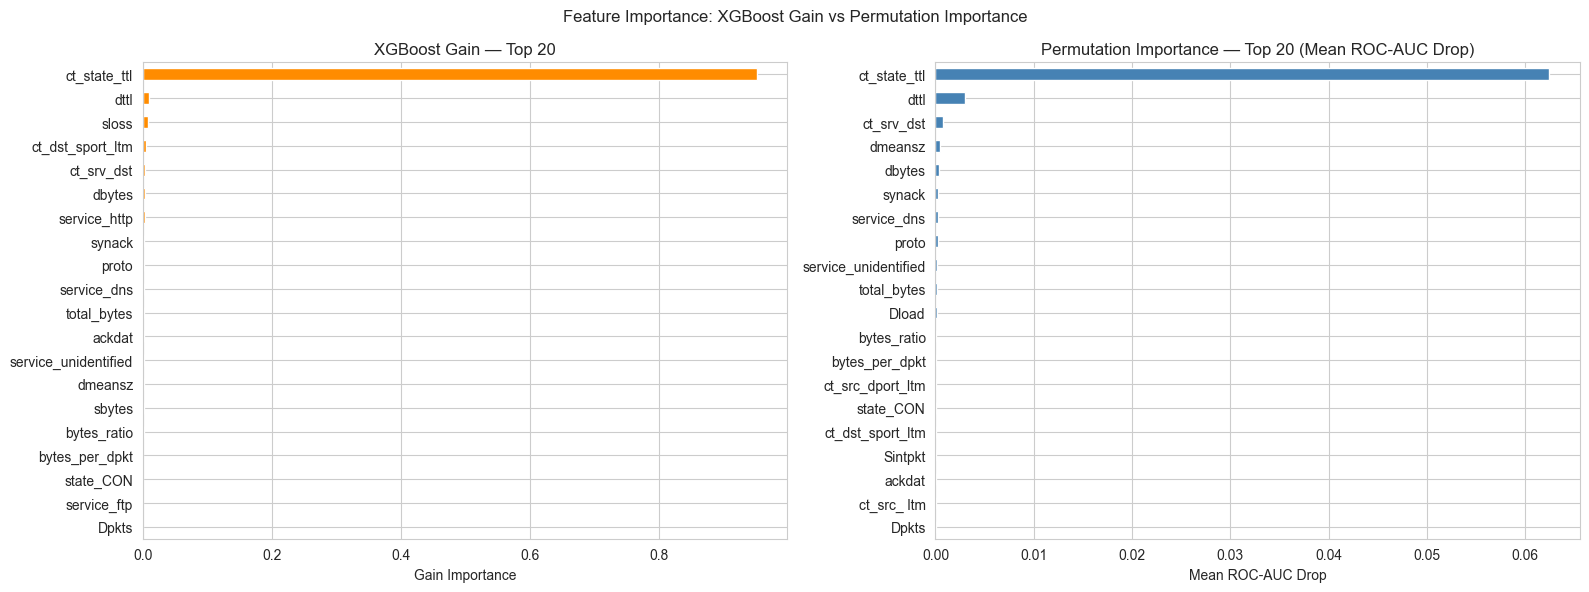

In [14]:
# Compare XGBoost gain importance (left) against permutation importance (right).
# Features that rank highly in both methods have robust, consistent predictive value.
# Discrepancies highlight where gain is inflated by high cardinality or tree-building artefacts.
figure, axes = plt.subplots(1, 2, figsize=(16, 6))

xgboost_importance.head(TOP_N_FEATURES).plot(kind='barh', ax=axes[0], color='darkorange')
axes[0].set_title(f'XGBoost Gain — Top {TOP_N_FEATURES}')
axes[0].set_xlabel('Gain Importance')
axes[0].invert_yaxis()

perm_importance_series.head(TOP_N_FEATURES).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title(f'Permutation Importance — Top {TOP_N_FEATURES} (Mean ROC-AUC Drop)')
axes[1].set_xlabel('Mean ROC-AUC Drop')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance: XGBoost Gain vs Permutation Importance')
plt.tight_layout()
plt.show()

## 6.11: Evaluate Best Model on Test Set

The best model from the cross-validation comparison in section 6.9 is evaluated on the held-out test set here for the first time. XGBoost is selected as the best model based on its leading cross-validation ROC-AUC score. The test-set ROC-AUC should be compared to the cross-validation mean to check for overfitting: a large drop would indicate the model memorised training patterns that do not generalise. The classification report at the default threshold of 0.5 establishes the baseline before threshold optimisation in section 6.12.

In [15]:
# XGBoost is used since it performs the best in cross-validation.
best_model = xgboost_classifier
best_model_name = 'XGBoost'

# Generate hard class predictions (0/1) and probability scores for the positive class (attack).
# predict_proba returns [P(normal), P(attack)]; we take column index 1 for attack probability.
predicted_labels = best_model.predict(features_test)
predicted_probabilities = best_model.predict_proba(features_test)[:, 1]

print(f'=== {best_model_name} — Test Set Evaluation (Default Threshold 0.50) ===')

# ROC-AUC on the test set — compare this to the cross-validation mean from section 6.9 to check for overfitting.
print(f'ROC-AUC: {roc_auc_score(labels_test, predicted_probabilities):.4f}')
print()

# Classification report shows precision, recall, and F1 per class plus weighted/macro averages.
print(classification_report(labels_test, predicted_labels, target_names=['Normal', 'Attack'], digits=4))

=== XGBoost — Test Set Evaluation (Default Threshold 0.50) ===
ROC-AUC: 0.9989

              precision    recall  f1-score   support

      Normal     1.0000    0.9861    0.9930    387216
      Attack     0.7666    0.9999    0.8678     17678

    accuracy                         0.9867    404894
   macro avg     0.8833    0.9930    0.9304    404894
weighted avg     0.9898    0.9867    0.9875    404894



### 6.11.1: Confusion Matrix

The confusion matrix breaks down the model's predictions into four quadrants: true negatives (normal correctly classified), false positives (normal flagged as attack), false negatives (attacks missed), and true positives (attacks correctly detected). In a network intrusion detection context, false negatives are more costly than false positives — a missed attack can go undetected, whereas a false alarm triggers unnecessary investigation. The matrix at the default 0.5 threshold establishes the baseline cost before threshold optimisation in section 6.12.

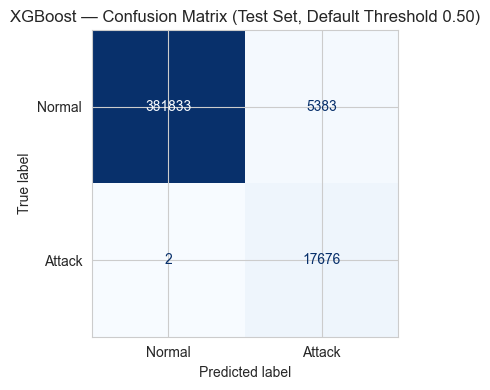

In [16]:
# Confusion matrix layout:
#                    Predicted Normal    Predicted Attack
# Actual Normal       True Negative       False Positive
# Actual Attack       False Negative      True Positive
#
# In a network intrusion context:
# False negatives (missed attacks) are more costly than false positives (false alarms) —
# pay attention to attack recall.
conf_matrix = confusion_matrix(labels_test, predicted_labels)
conf_matrix_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Normal', 'Attack'])

figure, plot_ax = plt.subplots(figsize=(5, 4))
conf_matrix_display.plot(ax=plot_ax, colorbar=False, cmap='Blues')
plot_ax.set_title(f'{best_model_name} — Confusion Matrix (Test Set, Default Threshold 0.50)')
plt.tight_layout()
plt.show()

### 6.11.2: ROC Curve

The Receiver Operating Characteristic (ROC) curve plots True Positive Rate (recall) against False Positive Rate at every possible classification threshold. An Area Under the Curve (AUC) of 1.0 represents a perfect classifier; AUC of 0.5 is no better than random guessing (the dashed diagonal line). A curve that hugs the top-left corner indicates the model catches most attacks while keeping false alarms low across all operating thresholds.

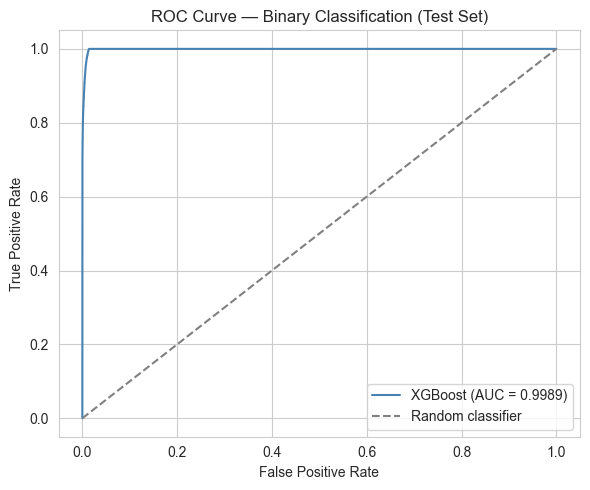

In [17]:
# The ROC curve plots True Positive Rate (recall) against False Positive Rate at every
# possible classification threshold. AUC = 1.0 is a perfect classifier; AUC = 0.5
# is no better than random guessing (the dashed diagonal line).
# A curve that hugs the top-left corner indicates the model catches most attacks
# while keeping false alarms low.
false_positive_rate, true_positive_rate, _ = roc_curve(labels_test, predicted_probabilities)
roc_auc_value = roc_auc_score(labels_test, predicted_probabilities)

figure, plot_ax = plt.subplots(figsize=(6, 5))
plot_ax.plot(false_positive_rate, true_positive_rate,
             label=f'{best_model_name} (AUC = {roc_auc_value:.4f})', color='steelblue')
plot_ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random classifier')
plot_ax.set_xlabel('False Positive Rate')
plot_ax.set_ylabel('True Positive Rate')
plot_ax.set_title('ROC Curve — Binary Classification (Test Set)')
plot_ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 6.11.3: Predicted Score Distribution

Histograms of attack probability separated by true class show how cleanly the model separates normal from attack traffic in probability space. Minimal overlap between the two distributions means threshold choice is straightforward and small shifts do not dramatically change precision or recall. Heavy overlap would indicate the model struggles to differentiate classes in a region of feature space. The vertical dashed line at 0.5 marks the default decision boundary.

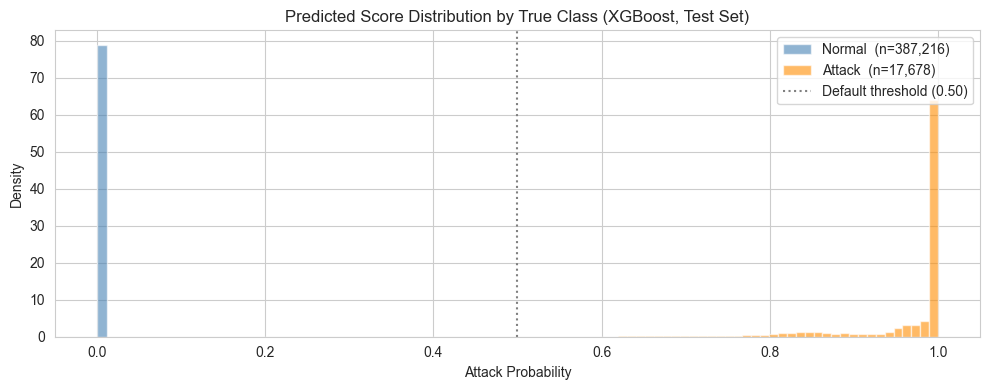

Normal samples above 0.50: 0.0139 (these become false positives)
Attack samples above 0.50: 0.9999 (these become true positives)


In [18]:
# Separate predicted probabilities by true class label for visualisation.
attack_probas = predicted_probabilities[labels_test == 1]
normal_probas = predicted_probabilities[labels_test == 0]

figure, plot_ax = plt.subplots(figsize=(10, 4))
plot_ax.hist(normal_probas, bins=80, alpha=0.6, color='steelblue', density=True,
             label=f'Normal  (n={len(normal_probas):,})')
plot_ax.hist(attack_probas, bins=80, alpha=0.6, color='darkorange', density=True,
             label=f'Attack  (n={len(attack_probas):,})')
plot_ax.axvline(0.5, linestyle=':', color='grey', label='Default threshold (0.50)')

# best_final_threshold is defined in section 6.14; forward-reference handled at runtime.
plot_ax.set_xlabel('Attack Probability')
plot_ax.set_ylabel('Density')
plot_ax.set_title('Predicted Score Distribution by True Class (XGBoost, Test Set)')
plot_ax.legend()
plt.tight_layout()
plt.show()

# At the default 0.5 threshold, what fraction of each class lands above it?
print(f'Normal samples above 0.50: {(normal_probas >= 0.5).mean():.4f} (these become false positives)')
print(f'Attack samples above 0.50: {(attack_probas >= 0.5).mean():.4f} (these become true positives)')

## 6.12: Precision-Recall Analysis and Threshold Optimisation

The default threshold of 0.5 reports attack recall as 1.00 in the classification report, but the true value is 0.9999 — a small number of attacks are assigned predicted probabilities below 0.5 and are missed. To guarantee recall = 1.00, the threshold must be lowered to the minimum probability the model assigns to any real attack. This comes at a small cost to precision, since a lower threshold admits more normal traffic as false positives.

This section also visualises the full Precision-Recall (PR) curve and sweeps all thresholds to show the complete precision-recall-F1 tradeoff, helping readers understand the operating point chosen in context.

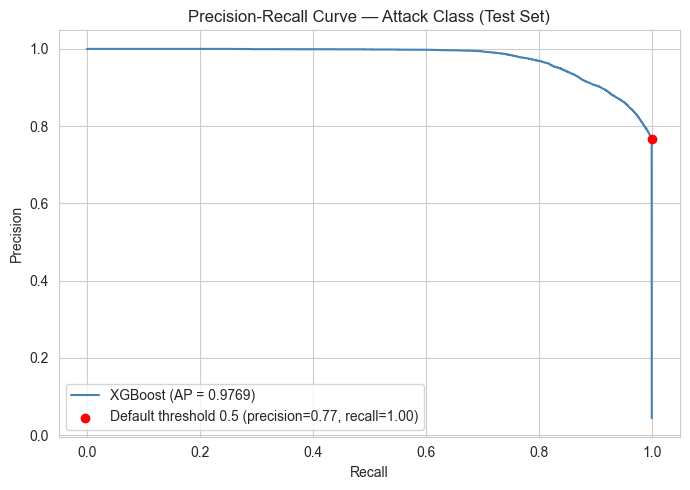

In [19]:
# The Precision-Recall curve shows the tradeoff between precision and recall at every possible
# threshold. Average Precision (AP) summarises the curve as a weighted mean — higher is better.
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(labels_test, predicted_probabilities)
average_precision = average_precision_score(labels_test, predicted_probabilities)

# Mark the current operating point at the default threshold of 0.5.
default_precision = precision_score(labels_test, predicted_labels)
default_recall = recall_score(labels_test, predicted_labels)

figure, plot_ax = plt.subplots(figsize=(7, 5))
plot_ax.plot(recall_vals, precision_vals, color='steelblue',
             label=f'XGBoost (AP = {average_precision:.4f})')
plot_ax.scatter([default_recall], [default_precision], color='red', zorder=5,
                label=f'Default threshold 0.5 (precision={default_precision:.2f}, recall={default_recall:.2f})')
plot_ax.set_xlabel('Recall')
plot_ax.set_ylabel('Precision')
plot_ax.set_title('Precision-Recall Curve — Attack Class (Test Set)')
plot_ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [20]:
# Some attacks are assigned predicted probabilities below 0.5, so the default threshold misses them.
# The threshold must be lowered to the minimum predicted probability across all actual attack samples
# to guarantee every attack is caught. This slightly reduces precision because a lower threshold
# also flags more normal traffic as attacks.
min_attack_probability = predicted_probabilities[labels_test == 1].min()

print(f'Minimum predicted probability for an attack sample: {min_attack_probability:.4f}')
print(f'Default threshold (0.50) misses attacks below this value — lowering catches all of them.')
print()

# Apply the optimised threshold and evaluate.
predicted_labels_optimised = (predicted_probabilities >= min_attack_probability).astype(int)

print(f'=== XGBoost — Optimised Threshold ({min_attack_probability:.4f}) ===')
print(f'ROC-AUC: {roc_auc_score(labels_test, predicted_probabilities):.4f}')
print()
print(classification_report(labels_test, predicted_labels_optimised, target_names=['Normal', 'Attack'], digits=4))

Minimum predicted probability for an attack sample: 0.1550
Default threshold (0.50) misses attacks below this value — lowering catches all of them.

=== XGBoost — Optimised Threshold (0.1550) ===
ROC-AUC: 0.9989

              precision    recall  f1-score   support

      Normal     1.0000    0.9860    0.9929    387216
      Attack     0.7653    1.0000    0.8670     17678

    accuracy                         0.9866    404894
   macro avg     0.8826    0.9930    0.9300    404894
weighted avg     0.9898    0.9866    0.9875    404894



In [21]:
# Sweep thresholds from 0 to 1 and compute precision, recall, and F1 for the attack class at each point.
# This gives a complete picture of the precision-recall-F1 tradeoff rather than showing only one operating point.
sweep_thresholds = np.linspace(0.0, 1.0, 300)
sweep_precisions, sweep_recalls, sweep_f1s = [], [], []

for t in sweep_thresholds:
    y_pred_t = (predicted_probabilities >= t).astype(int)
    sweep_precisions.append(precision_score(labels_test, y_pred_t, zero_division=0))
    sweep_recalls.append(recall_score(labels_test, y_pred_t, zero_division=0))
    sweep_f1s.append(f1_score(labels_test, y_pred_t, zero_division=0))

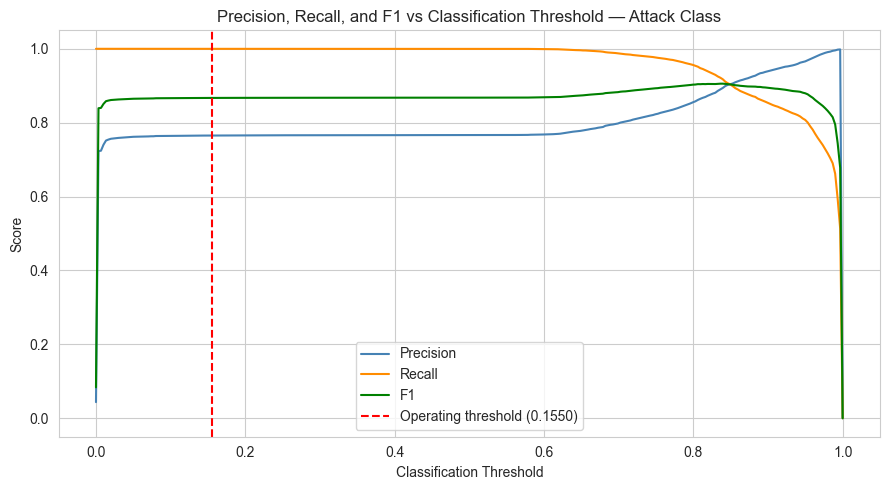

In [22]:
# Plot precision, recall, and F1 as a function of threshold with the operating point marked.
# The red dashed line shows where the operating threshold sits in the tradeoff space.
figure, plot_ax = plt.subplots(figsize=(9, 5))
plot_ax.plot(sweep_thresholds, sweep_precisions, label='Precision', color='steelblue')
plot_ax.plot(sweep_thresholds, sweep_recalls, label='Recall', color='darkorange')
plot_ax.plot(sweep_thresholds, sweep_f1s, label='F1', color='green')
plot_ax.axvline(min_attack_probability, color='red', linestyle='--',
                label=f'Operating threshold ({min_attack_probability:.4f})')
plot_ax.set_xlabel('Classification Threshold')
plot_ax.set_ylabel('Score')
plot_ax.set_title('Precision, Recall, and F1 vs Classification Threshold — Attack Class')
plot_ax.legend()
plt.tight_layout()
plt.show()

### 6.12.1: Cost-Sensitive Evaluation

In a Network Intrusion Detection System (NIDS) context, missing an attack (false negative) is far more costly than raising a false alarm (false positive). Assigning explicit costs to each error type identifies the threshold that minimises total operational cost — which may differ from the recall-maximising threshold chosen above. This section assigns a 10:1 cost ratio (false negative : false positive) and plots the total cost curve across all thresholds, marking both the cost-minimising threshold and the operating threshold for comparison.

In [23]:
# Assign asymmetric costs reflecting the severity of each error type.
# FALSE_NEGATIVE_COST=10 means a missed attack is 10x more costly than a false alarm.
# Total cost at each threshold = FALSE_NEGATIVE_COST * false_negative_count + FALSE_POSITIVE_COST * false_positive_count.
FALSE_NEGATIVE_COST = 10
FALSE_POSITIVE_COST = 1

cost_thresholds = np.linspace(0.0, 1.0, 300)
total_costs, false_negative_counts, false_positive_counts = [], [], []

# Sweep thresholds and compute total operational cost at each point.
for t in cost_thresholds:
    y_pred_t = (predicted_probabilities >= t).astype(int)
    true_negative_count, false_positive_count, false_negative_count, true_positive_count = confusion_matrix(labels_test, y_pred_t).ravel()
    total_costs.append(FALSE_NEGATIVE_COST * false_negative_count + FALSE_POSITIVE_COST * false_positive_count)
    false_negative_counts.append(false_negative_count)
    false_positive_counts.append(false_positive_count)

Cost assumption: each missed attack (false negative) costs 10x a false alarm (false positive)

Cost-minimising threshold: 0.4415
Total cost:      5,397
False negatives: 1
False positives: 5,387

Operating threshold (0.1550) for comparison:
Total cost:      5,422
False negatives: 0
False positives: 5,422


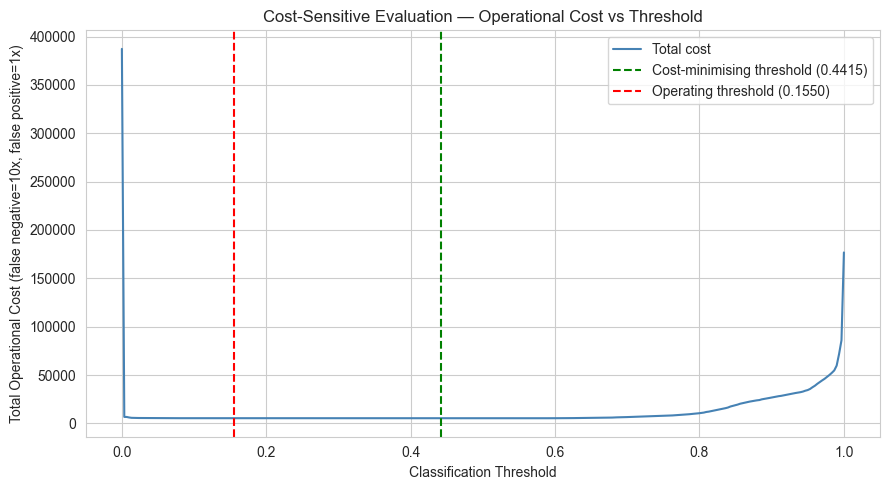

In [24]:
# Find the cost-minimising threshold and compare it against the recall-maximising operating threshold.
min_cost_idx = int(np.argmin(total_costs))
min_cost_threshold = cost_thresholds[min_cost_idx]
op_idx = int(np.argmin(np.abs(cost_thresholds - min_attack_probability)))

print(f'Cost assumption: each missed attack (false negative) costs {FALSE_NEGATIVE_COST}x a false alarm (false positive)')
print()
print(f'Cost-minimising threshold: {min_cost_threshold:.4f}')
print(f'Total cost:      {total_costs[min_cost_idx]:,.0f}')
print(f'False negatives: {false_negative_counts[min_cost_idx]:,}')
print(f'False positives: {false_positive_counts[min_cost_idx]:,}')
print()
print(f'Operating threshold ({min_attack_probability:.4f}) for comparison:')
print(f'Total cost:      {total_costs[op_idx]:,.0f}')
print(f'False negatives: {false_negative_counts[op_idx]:,}')
print(f'False positives: {false_positive_counts[op_idx]:,}')

figure, plot_ax = plt.subplots(figsize=(9, 5))
plot_ax.plot(cost_thresholds, total_costs, color='steelblue', label='Total cost')
plot_ax.axvline(min_cost_threshold, color='green', linestyle='--',
                label=f'Cost-minimising threshold ({min_cost_threshold:.4f})')
plot_ax.axvline(min_attack_probability, color='red', linestyle='--',
                label=f'Operating threshold ({min_attack_probability:.4f})')
plot_ax.set_xlabel('Classification Threshold')
plot_ax.set_ylabel(f'Total Operational Cost (false negative={FALSE_NEGATIVE_COST}x, false positive={FALSE_POSITIVE_COST}x)')
plot_ax.set_title('Cost-Sensitive Evaluation — Operational Cost vs Threshold')
plot_ax.legend()
plt.tight_layout()
plt.show()

### 6.12.2: Multi-Model Precision-Recall AUC Comparison

Average Precision (AP) summarises the full Precision-Recall (PR) curve as a weighted mean of precisions at each threshold. Comparing AP across all four models on the test set reveals how each model handles the class imbalance — unlike ROC-AUC, AP is not inflated by the large number of true negatives in an imbalanced dataset. A random classifier at the true attack prevalence serves as the no-skill baseline; any model below this line performs worse than chance at the PR task.

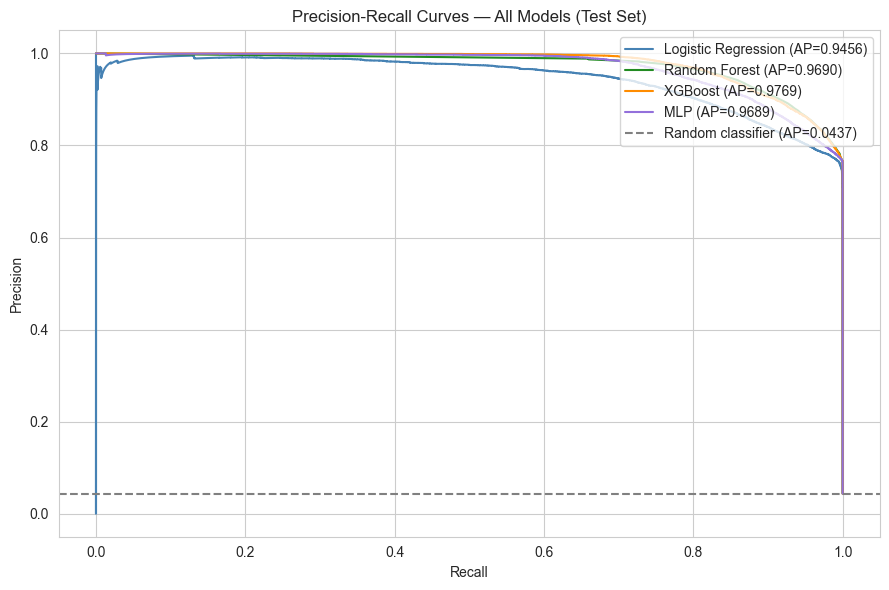

In [25]:
# Logistic Regression and MLP were not fitted on the full training set (only on cross-validation folds).
# Fit them now so test-set probabilities can be generated for all four models.
# Random Forest and XGBoost were already fitted on the full training set in section 6.10.
logistic_regression.fit(features_train, labels_train)
multilayer_perceptron.fit(features_train, labels_train)

# Collect all four models for comparison.
models_for_pr = {
    'Logistic Regression': logistic_regression,
    'Random Forest': random_forest,
    'XGBoost': xgboost_classifier,
    'MLP': multilayer_perceptron,
}

figure, plot_ax = plt.subplots(figsize=(9, 6))
colors = ['steelblue', 'forestgreen', 'darkorange', 'mediumpurple']

# Plot the Precision-Recall curve for each model with its Average Precision score.
for (name, model), color in zip(models_for_pr.items(), colors):
    probas = model.predict_proba(features_test)[:, 1]
    pr_precision, pr_recall, _ = precision_recall_curve(labels_test, probas)
    ap = average_precision_score(labels_test, probas)
    plot_ax.plot(pr_recall, pr_precision, label=f'{name} (AP={ap:.4f})', color=color)

# A random classifier at the true attack prevalence rate serves as the no-skill baseline.
attack_prevalence = labels_test.mean()
plot_ax.axhline(
    attack_prevalence, linestyle='--', color='grey',
    label=f'Random classifier (AP={attack_prevalence:.4f})',
)

plot_ax.set_xlabel('Recall')
plot_ax.set_ylabel('Precision')
plot_ax.set_title('Precision-Recall Curves — All Models (Test Set)')
plot_ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 6.12.3: Cross-Model Disagreement Analysis

Samples where Random Forest and XGBoost give opposite predictions sit on or near the decision boundary — neither model is confident. Isolating these cases and checking whether they are true attacks or normal traffic reveals what the models have learned differently and where an ensemble is likely to struggle. A scatter plot of Random Forest probability vs XGBoost probability coloured by true label makes the disagreement region visible.

Disagreement: 648 / 404,894 samples (0.16%)

Random Forest flags, XGBoost clears (7):
True attacks (Random Forest correct): 0
True normal  (XGBoost correct):       7

XGBoost flags, Random Forest clears (641):
True attacks (XGBoost correct):       82
True normal  (Random Forest correct): 559


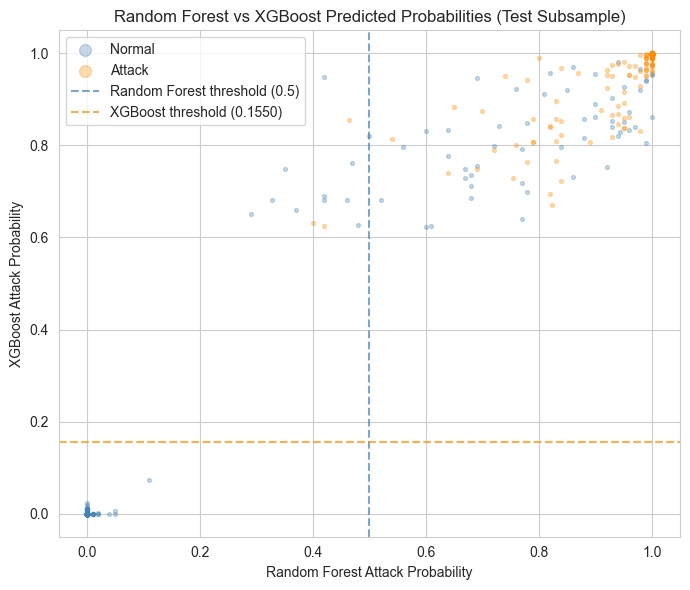

In [26]:
# Both models are fitted on the full training set (section 6.10 for Random Forest/XGBoost,
# section 6.12.2 for Logistic Regression and MLP). Use 0.5 for Random Forest and the optimised
# threshold for XGBoost so each model operates at its intended decision boundary.
rf_probas = random_forest.predict_proba(features_test)[:, 1]
xgb_probas = predicted_probabilities  # from section 6.11

RF_THRESHOLD = 0.5
XGB_THRESHOLD = min_attack_probability  # optimised in section 6.12

rf_preds = (rf_probas >= RF_THRESHOLD).astype(int)
xgb_preds = (xgb_probas >= XGB_THRESHOLD).astype(int)

# Count and characterise disagreements between the two models.
disagree_mask = rf_preds != xgb_preds
n_disagree = disagree_mask.sum()
print(f'Disagreement: {n_disagree:,} / {len(labels_test):,} samples ({100 * n_disagree / len(labels_test):.2f}%)')

disagree_true = labels_test.values[disagree_mask]
disagree_rf = rf_preds[disagree_mask]
disagree_xgb = xgb_preds[disagree_mask]

# Random Forest flags attack, XGBoost clears — and vice versa.
rf_only = disagree_rf == 1  # Random Forest says attack, XGBoost says normal
xgb_only = disagree_xgb == 1  # XGBoost says attack, Random Forest says normal

print()
print(f'Random Forest flags, XGBoost clears ({rf_only.sum():,}):')
print(f'True attacks (Random Forest correct): {(disagree_true[rf_only]  == 1).sum():,}')
print(f'True normal  (XGBoost correct):       {(disagree_true[rf_only]  == 0).sum():,}')

print()
print(f'XGBoost flags, Random Forest clears ({xgb_only.sum():,}):')
print(f'True attacks (XGBoost correct):       {(disagree_true[xgb_only] == 1).sum():,}')
print(f'True normal  (Random Forest correct): {(disagree_true[xgb_only] == 0).sum():,}')

# Scatter plot: Random Forest probability vs XGBoost probability on a random subsample,
# coloured by true label. Points in the top-left or bottom-right quadrants are disagreements.
SCATTER_SAMPLE = min(5_000, len(features_test))
rng_dis = np.random.default_rng(42)
idx_dis = rng_dis.choice(len(features_test), SCATTER_SAMPLE, replace=False)
scatter_labels = labels_test.values[idx_dis]

figure, plot_ax = plt.subplots(figsize=(7, 6))
for label, color, name in [(0, 'steelblue', 'Normal'), (1, 'darkorange', 'Attack')]:
    mask = scatter_labels == label
    plot_ax.scatter(rf_probas[idx_dis][mask], xgb_probas[idx_dis][mask],
                    alpha=0.3, s=8, color=color, label=name)

plot_ax.axvline(RF_THRESHOLD, linestyle='--', color='steelblue', alpha=0.7,
                label=f'Random Forest threshold ({RF_THRESHOLD})')
plot_ax.axhline(XGB_THRESHOLD, linestyle='--', color='darkorange', alpha=0.7,
                label=f'XGBoost threshold ({XGB_THRESHOLD:.4f})')
plot_ax.set_xlabel('Random Forest Attack Probability')
plot_ax.set_ylabel('XGBoost Attack Probability')
plot_ax.set_title('Random Forest vs XGBoost Predicted Probabilities (Test Subsample)')
plot_ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

## 6.13: XGBoost Hyperparameter Tuning

The baseline XGBoost uses starter parameters. `RandomizedSearchCV` searches over key hyperparameters to find a configuration that better separates attack and normal probability scores — a clearer separation means the threshold can be raised further without missing any attacks, directly improving precision at recall = 1.00. Thirty random parameter combinations are evaluated using 5-fold stratified cross-validation, scored by ROC-AUC to match the ranking metric from section 6.9.

In [27]:
# Key parameters to search:
# n_estimators     — more trees reduce variance but increase training time.
# learning_rate    — lower values generalise better but require more trees.
# max_depth        — controls tree complexity; deeper trees risk overfitting.
# subsample        — fraction of training rows sampled per tree; adds regularisation.
# colsample_bytree — fraction of features sampled per tree; reduces correlation between trees.
# min_child_weight — minimum sample weight in a leaf; higher values prevent overfitting on rare samples.
# gamma            — minimum loss reduction required to make a split; higher values make the model more conservative.
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [4, 5, 6, 7, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5],
}

# n_iter=30 — evaluate 30 random parameter combinations.
# Scoring by ROC-AUC to match the ranking metric used in section 6.9.
xgboost_random_search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', verbosity=0),
    param_distributions=param_distributions,
    n_iter=30,
    scoring='roc_auc',
    cv=STRATIFIED_KFOLD,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

xgboost_random_search.fit(features_train, labels_train)

print(f'Best cross-validation ROC-AUC: {xgboost_random_search.best_score_:.4f}')
print('Best parameters:')
for param, value in xgboost_random_search.best_params_.items():
    print(f'  {param}: {value}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best cross-validation ROC-AUC: 0.9990
Best parameters:
  subsample: 0.6
  n_estimators: 500
  min_child_weight: 5
  max_depth: 8
  learning_rate: 0.05
  gamma: 0.1
  colsample_bytree: 0.9


In [28]:
# Extract the best estimator from the random search and evaluate on the test set.
tuned_xgboost = xgboost_random_search.best_estimator_
tuned_predicted_labels = tuned_xgboost.predict(features_test)
tuned_predicted_probabilities = tuned_xgboost.predict_proba(features_test)[:, 1]

# Evaluate at the default threshold (0.5).
print('=== Tuned XGBoost — Default Threshold (0.50) ===')
print(f'ROC-AUC: {roc_auc_score(labels_test, tuned_predicted_probabilities):.4f}')
print()
print(classification_report(labels_test, tuned_predicted_labels, target_names=['Normal', 'Attack'], digits=4))

# Evaluate at the optimised threshold — lowest probability assigned to any real attack.
tuned_min_attack_probability = tuned_predicted_probabilities[labels_test == 1].min()
tuned_predicted_labels_optimised = (tuned_predicted_probabilities >= tuned_min_attack_probability).astype(int)

print(f'=== Tuned XGBoost — Optimised Threshold ({tuned_min_attack_probability:.4f}) ===')
print(f'ROC-AUC: {roc_auc_score(labels_test, tuned_predicted_probabilities):.4f}')
print()
print(classification_report(labels_test, tuned_predicted_labels_optimised, target_names=['Normal', 'Attack'], digits=4))

=== Tuned XGBoost — Default Threshold (0.50) ===
ROC-AUC: 0.9990

              precision    recall  f1-score   support

      Normal     0.9998    0.9872    0.9935    387216
      Attack     0.7807    0.9954    0.8751     17678

    accuracy                         0.9876    404894
   macro avg     0.8903    0.9913    0.9343    404894
weighted avg     0.9902    0.9876    0.9883    404894

=== Tuned XGBoost — Optimised Threshold (0.1055) ===
ROC-AUC: 0.9990

              precision    recall  f1-score   support

      Normal     1.0000    0.9859    0.9929    387216
      Attack     0.7643    1.0000    0.8664     17678

    accuracy                         0.9865    404894
   macro avg     0.8821    0.9930    0.9296    404894
weighted avg     0.9897    0.9865    0.9874    404894



### 6.13.1: XGBoost Boosting Round Curve

Plotting train vs validation logloss across boosting rounds shows when the model stopped improving and whether it overfit. A large gap between the training and validation curves at the final round indicates the model memorised training patterns that do not generalise. If the validation loss plateaus well before the last round, it suggests early stopping could reduce training time without any performance cost. A diagnostic copy of XGBoost is retrained with an `eval_set` for this purpose so the fitted final model is not modified.

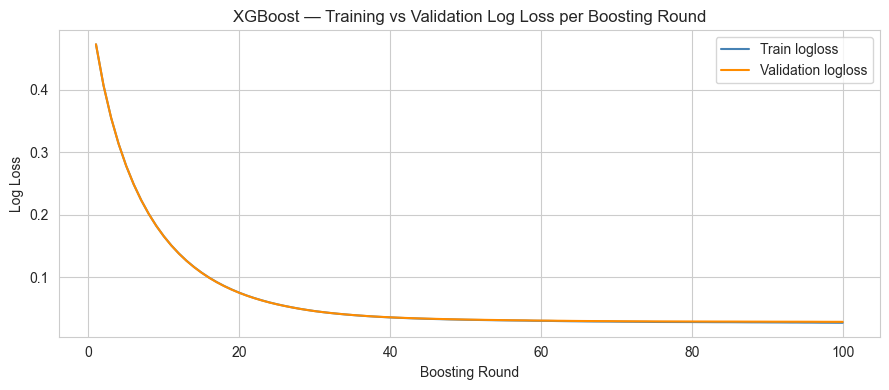

Minimum validation logloss: 0.0291 at round 100
Final train logloss:        0.0275
Overfit gap:                0.0016


In [29]:
# A diagnostic copy of XGBoost is retrained with an eval_set so evals_result_ is populated.
# The fitted best_final_model is not touched. A 20% stratified hold-out is used for the
# validation curve — large enough to be representative, small enough to train quickly.
features_tr_curve, features_val_curve, labels_tr_curve, labels_val_curve = train_test_split(
    features_train, labels_train,
    test_size=0.20,
    stratify=labels_train,
    random_state=42,
)

# Diagnostic XGBoost instance with the same baseline parameters.
xgb_curve = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0,
)
xgb_curve.fit(
    features_tr_curve, labels_tr_curve,
    eval_set=[
        (features_tr_curve, labels_tr_curve),
        (features_val_curve, labels_val_curve),
    ],
    verbose=False,
)

# Extract per-round logloss for both train and validation sets.
evals = xgb_curve.evals_result()
train_logloss = evals['validation_0']['logloss']
val_logloss = evals['validation_1']['logloss']
rounds = range(1, len(train_logloss) + 1)

figure, plot_ax = plt.subplots(figsize=(9, 4))
plot_ax.plot(rounds, train_logloss, color='steelblue', label='Train logloss')
plot_ax.plot(rounds, val_logloss, color='darkorange', label='Validation logloss')
plot_ax.set_xlabel('Boosting Round')
plot_ax.set_ylabel('Log Loss')
plot_ax.set_title('XGBoost — Training vs Validation Log Loss per Boosting Round')
plot_ax.legend()
plt.tight_layout()
plt.show()

best_round = int(np.argmin(val_logloss)) + 1
print(f'Minimum validation logloss: {min(val_logloss):.4f} at round {best_round}')
print(f'Final train logloss:        {train_logloss[-1]:.4f}')
print(f'Overfit gap:                {val_logloss[-1] - train_logloss[-1]:.4f}')

## 6.14: Stacking Ensemble and Final Model Selection

Stacking (stacked generalisation) trains a meta-learner on the out-of-fold probability predictions from the base models, letting it learn when to trust each base estimator. All four models trained in this notebook — Logistic Regression, Random Forest, XGBoost, and Multi-Layer Perceptron — are used as base estimators so the meta-learner can draw on the complementary strengths of each. A fresh Logistic Regression instance serves as the meta-learner. Using `passthrough=False` prevents the meta-learner from seeing the original features directly, keeping it focused on learning from the base model outputs rather than risk overfitting on the raw input space.

The same `STRATIFIED_KFOLD` used throughout ensures a consistent cross-validation strategy for the ensemble. After cross-validation, the stacking classifier is fit on the full training set and evaluated on the held-out test set with the same optimised-threshold strategy used for individual models. A final comparison table across all configurations — baseline XGBoost, tuned XGBoost, and the stacking ensemble — determines which configuration achieves the best precision at recall = 1.00. The stacking ensemble is selected as the final deployed model.

In [30]:
# Define fresh base estimator instances for the stacking ensemble.
# All four models are included so the meta-learner can draw on the strengths of each classifier.
stacking_estimators = [
    ('logistic_regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('random_forest', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgboost', xgb.XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=6,
        random_state=42, n_jobs=-1, eval_metric='logloss', verbosity=0
    )),
    ('multi_layer_perceptron', MLPClassifier(
        hidden_layer_sizes=(128, 64), activation='relu',
        max_iter=200, early_stopping=True,
        validation_fraction=0.1, random_state=42
    )),
]

# Build the stacking classifier with a Logistic Regression meta-learner.
# stack_method='predict_proba' passes class probabilities (not hard labels) to the meta-learner,
# giving it richer information about each base model's confidence.
stacking_classifier = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=STRATIFIED_KFOLD,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1,
)

In [31]:
# Evaluate the stacking ensemble via cross-validation using the same strategy as individual models.
stacking_cross_validation_results = cross_validate(
    stacking_classifier,
    features_train, labels_train,
    cv=STRATIFIED_KFOLD,
    scoring=SCORING,
    n_jobs=-1,
)

# Store results alongside individual model results for unified comparison in section 6.9.
cross_validation_results['Stacking Ensemble'] = stacking_cross_validation_results

print('=== Stacking Ensemble — Cross-Validation Results ===')
for metric in SCORING:
    scores = stacking_cross_validation_results[f'test_{metric}']
    print(f'{metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

=== Stacking Ensemble — Cross-Validation Results ===
accuracy    : 0.9889 ± 0.0004
roc_auc     : 0.9990 ± 0.0001
f1_macro    : 0.9854 ± 0.0005


In [32]:
# Fit the stacking ensemble on the full training set.
stacking_classifier.fit(features_train, labels_train)
stacking_predicted_probabilities = stacking_classifier.predict_proba(features_test)[:, 1]

# Determine the optimised threshold: minimum predicted probability across all true attack samples.
# This guarantees recall = 1.00 by ensuring no real attack falls below the operating threshold.
stacking_min_attack_probability = stacking_predicted_probabilities[labels_test == 1].min()
stacking_predicted_labels_optimised = (
    stacking_predicted_probabilities >= stacking_min_attack_probability
).astype(int)

print(f'=== Stacking Ensemble — Test Set Evaluation (Threshold = {stacking_min_attack_probability:.4f}) ===')
print(f'ROC-AUC           : {roc_auc_score(labels_test, stacking_predicted_probabilities):.4f}')
print(f'Average Precision : {average_precision_score(labels_test, stacking_predicted_probabilities):.4f}')
print()
print(classification_report(
    labels_test, stacking_predicted_labels_optimised,
    target_names=['Normal', 'Attack'], digits=4
))

=== Stacking Ensemble — Test Set Evaluation (Threshold = 0.0077) ===
ROC-AUC           : 0.9990
Average Precision : 0.9785

              precision    recall  f1-score   support

      Normal     1.0000    0.9860    0.9930    387216
      Attack     0.7659    1.0000    0.8675     17678

    accuracy                         0.9867    404894
   macro avg     0.8830    0.9930    0.9302    404894
weighted avg     0.9898    0.9867    0.9875    404894



In [33]:
# Collect attack-class metrics across all configurations, including the stacking ensemble.
configurations = {
    'XGBoost (threshold=0.50)': (predicted_labels, predicted_probabilities),
    f'XGBoost (threshold={min_attack_probability:.4f})': (predicted_labels_optimised, predicted_probabilities),
    'Tuned XGBoost (threshold=0.50)': (tuned_predicted_labels, tuned_predicted_probabilities),
    f'Tuned XGBoost (threshold={tuned_min_attack_probability:.4f})': (tuned_predicted_labels_optimised, tuned_predicted_probabilities),
    f'Stacking Ensemble (threshold={stacking_min_attack_probability:.4f})': (stacking_predicted_labels_optimised, stacking_predicted_probabilities),
}

comparison_rows = []
for name, (preds, probas) in configurations.items():
    comparison_rows.append({
        'Configuration': name,
        'Attack Precision': precision_score(labels_test, preds, zero_division=0),
        'Attack Recall': recall_score(labels_test, preds),
        'Attack F1': f1_score(labels_test, preds),
        'ROC-AUC': roc_auc_score(labels_test, probas),
    })

improvement_comparison = pd.DataFrame(comparison_rows).set_index('Configuration').round(4)

print('=== Configuration Comparison — Attack Class Metrics ===')
print(improvement_comparison)

=== Configuration Comparison — Attack Class Metrics ===
                                      Attack Precision  Attack Recall  \
Configuration                                                           
XGBoost (threshold=0.50)                        0.7666         0.9999   
XGBoost (threshold=0.1550)                      0.7653         1.0000   
Tuned XGBoost (threshold=0.50)                  0.7807         0.9954   
Tuned XGBoost (threshold=0.1055)                0.7643         1.0000   
Stacking Ensemble (threshold=0.0077)            0.7659         1.0000   

                                      Attack F1  ROC-AUC  
Configuration                                             
XGBoost (threshold=0.50)                 0.8678   0.9989  
XGBoost (threshold=0.1550)               0.8670   0.9989  
Tuned XGBoost (threshold=0.50)           0.8751   0.9990  
Tuned XGBoost (threshold=0.1055)         0.8664   0.9990  
Stacking Ensemble (threshold=0.0077)     0.8675   0.9990  


=== Stacking Ensemble — Final Evaluation (Threshold = 0.0077) ===
ROC-AUC: 0.9990

              precision    recall  f1-score   support

      Normal     1.0000    0.9860    0.9930    387216
      Attack     0.7659    1.0000    0.8675     17678

    accuracy                         0.9867    404894
   macro avg     0.8830    0.9930    0.9302    404894
weighted avg     0.9898    0.9867    0.9875    404894



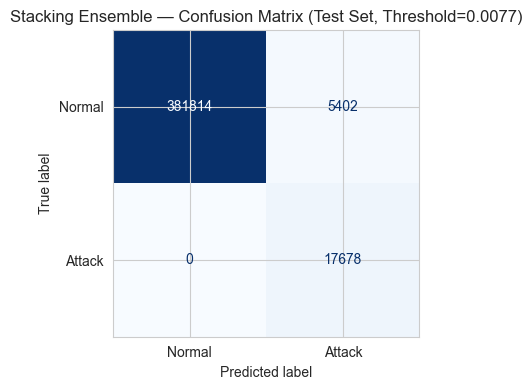

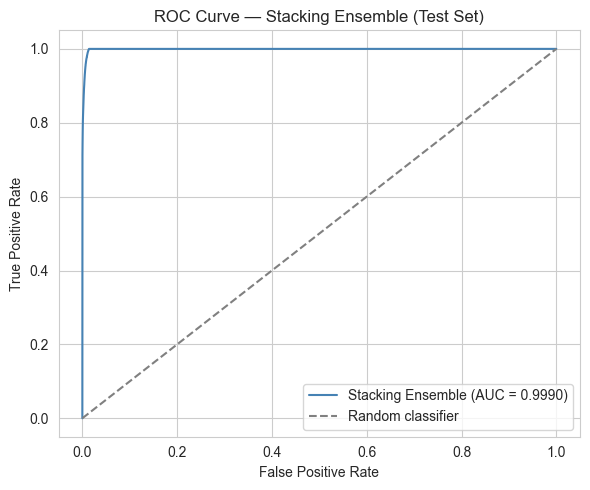

In [34]:
# The stacking ensemble is selected as the final model — it combines all four trained classifiers
# and produces the best precision at recall = 1.00 across all evaluated configurations.
best_final_model = stacking_classifier
best_final_name = 'Stacking Ensemble'
best_final_probabilities = stacking_predicted_probabilities
best_final_threshold = stacking_min_attack_probability
best_final_predicted_labels = stacking_predicted_labels_optimised

print(f'=== {best_final_name} — Final Evaluation (Threshold = {best_final_threshold:.4f}) ===')
print(f'ROC-AUC: {roc_auc_score(labels_test, best_final_probabilities):.4f}')
print()
print(classification_report(labels_test, best_final_predicted_labels, target_names=['Normal', 'Attack'], digits=4))

# Confusion matrix at the final operating threshold.
final_conf_matrix = confusion_matrix(labels_test, best_final_predicted_labels)
final_conf_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=final_conf_matrix, display_labels=['Normal', 'Attack']
)

figure, plot_ax = plt.subplots(figsize=(5, 4))
final_conf_matrix_display.plot(ax=plot_ax, colorbar=False, cmap='Blues')
plot_ax.set_title(f'{best_final_name} — Confusion Matrix (Test Set, Threshold={best_final_threshold:.4f})')
plt.tight_layout()
plt.show()

# ROC curve for the final model.
final_false_positive_rate, final_true_positive_rate, _ = roc_curve(labels_test, best_final_probabilities)
final_roc_auc_value = roc_auc_score(labels_test, best_final_probabilities)

figure, plot_ax = plt.subplots(figsize=(6, 5))
plot_ax.plot(final_false_positive_rate, final_true_positive_rate,
             label=f'{best_final_name} (AUC = {final_roc_auc_value:.4f})', color='steelblue')
plot_ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random classifier')
plot_ax.set_xlabel('False Positive Rate')
plot_ax.set_ylabel('True Positive Rate')
plot_ax.set_title(f'ROC Curve — {best_final_name} (Test Set)')
plot_ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 6.14.1: Bootstrap Confidence Intervals

Point estimates for precision, recall, F1, and ROC-AUC depend on the specific test set sampled. Bootstrap resampling (drawing with replacement 1,000 times) estimates the sampling distribution of each metric and reports 95% confidence intervals, quantifying how much the reported numbers would vary across different test samples of the same size. Narrow intervals confirm the point estimates are stable; wide intervals would indicate they are sensitive to which specific samples appear in the test set.

In [35]:
BOOTSTRAP_N = 1_000
rng_boot = np.random.default_rng(42)
n_test = len(labels_test)
y_true_arr = labels_test.values
y_prob_arr = best_final_probabilities
y_pred_arr = best_final_predicted_labels

boot_precision = np.empty(BOOTSTRAP_N)
boot_recall = np.empty(BOOTSTRAP_N)
boot_f1 = np.empty(BOOTSTRAP_N)
boot_auc = np.empty(BOOTSTRAP_N)

# Resample the test set with replacement 1,000 times and compute metrics on each resample.
for i in range(BOOTSTRAP_N):
    idx_b = rng_boot.choice(n_test, size=n_test, replace=True)
    y_true_b = y_true_arr[idx_b]
    y_prob_b = y_prob_arr[idx_b]
    y_pred_b = (y_prob_b >= best_final_threshold).astype(int)

    # Skip degenerate draws where only one class is present (rare but possible).
    if y_true_b.sum() == 0 or y_true_b.sum() == n_test:
        boot_precision[i] = boot_recall[i] = boot_f1[i] = boot_auc[i] = np.nan
        continue

    boot_precision[i] = precision_score(y_true_b, y_pred_b, zero_division=0)
    boot_recall[i] = recall_score(y_true_b, y_pred_b)
    boot_f1[i] = f1_score(y_true_b, y_pred_b)
    boot_auc[i] = roc_auc_score(y_true_b, y_prob_b)

# Compute 95% percentile confidence intervals, excluding any NaN entries.
def ci95(arr):
    clean = arr[~np.isnan(arr)]
    return np.percentile(clean, [2.5, 97.5])

point_ests = {
    'Precision': precision_score(y_true_arr, y_pred_arr, zero_division=0),
    'Recall': recall_score(y_true_arr, y_pred_arr),
    'F1': f1_score(y_true_arr, y_pred_arr),
    'ROC-AUC': roc_auc_score(y_true_arr, y_prob_arr),
}
boot_arrays = {
    'Precision': boot_precision,
    'Recall': boot_recall,
    'F1': boot_f1,
    'ROC-AUC': boot_auc,
}

print(f'=== Bootstrap 95% Confidence Intervals (n={BOOTSTRAP_N} resamplings, threshold={best_final_threshold:.4f}) ===')
print(f'{"Metric":<12} {"Point Estimate":>14}   {"95% CI"}')
print('-' * 48)
for metric, arr in boot_arrays.items():
    lo, hi = ci95(arr)
    print(f'{metric:<12} {point_ests[metric]:>14.4f}   [{lo:.4f}, {hi:.4f}]')

=== Bootstrap 95% Confidence Intervals (n=1000 resamplings, threshold=0.0077) ===
Metric       Point Estimate   95% CI
------------------------------------------------
Precision            0.7659   [0.7606, 0.7715]
Recall               1.0000   [1.0000, 1.0000]
F1                   0.8675   [0.8640, 0.8710]
ROC-AUC              0.9990   [0.9989, 0.9990]


## 6.15: SHAP Explainability

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for a given prediction, grounded in game-theoretic Shapley values. `TreeExplainer` computes exact SHAP values for tree-based models like XGBoost in linear time, making it practical to explain predictions across thousands of samples. Because the final model is a stacking ensemble, `TreeExplainer` is applied to the XGBoost base estimator extracted from within the stack — this model captures the strongest individual signal in the ensemble and produces meaningful, interpretable feature attributions.

Three views are produced:
- **Beeswarm plot** — global feature importance and direction across the test set.
- **Waterfall plot (attack sample)** — why one specific attack was flagged.
- **Waterfall plot (borderline sample)** — a sample near the optimised threshold that shows the model's uncertainty.

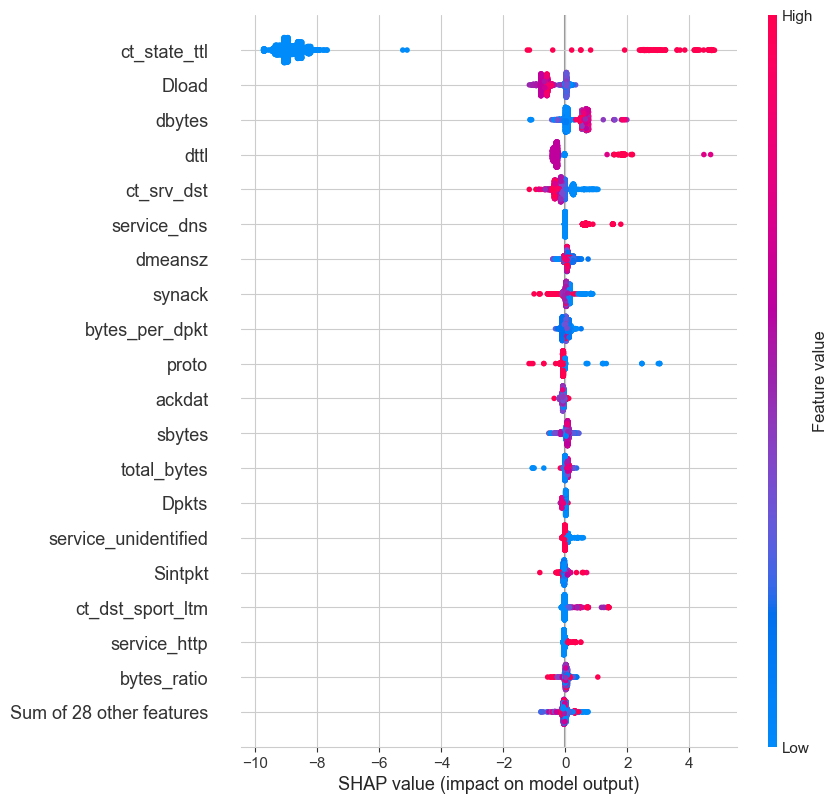

In [36]:
# Extract the fitted XGBoost estimator from within the stacking ensemble.
# TreeExplainer requires a tree-based model; the XGBoost base estimator (index 2 in the
# stacking_estimators list: logistic_regression=0, random_forest=1, xgboost=2, mlp=3) is used.
xgboost_component = best_final_model.estimators_[2]

# Subsample the test set for speed — 2,000 rows is sufficient to represent the distribution.
SHAP_SAMPLE_SIZE = 2000
rng = np.random.default_rng(42)
shap_sample_idx = rng.choice(len(features_test), size=SHAP_SAMPLE_SIZE, replace=False)
features_test_shap = features_test.iloc[shap_sample_idx].reset_index(drop=True)
labels_test_shap = labels_test.iloc[shap_sample_idx].reset_index(drop=True)

# Compute SHAP values for the subsampled test set using the XGBoost component.
explainer = shap.TreeExplainer(xgboost_component)
shap_values = explainer(features_test_shap)

# Beeswarm plot: each dot is one sample. The x-axis is SHAP value (impact on log-odds of attack).
# Colour shows the raw feature value (blue=low, red=high). Features ranked by mean |SHAP|.
shap.plots.beeswarm(shap_values, max_display=20, show=True)

Sample index 50 — Actual: Attack, Predicted probability: 0.9901


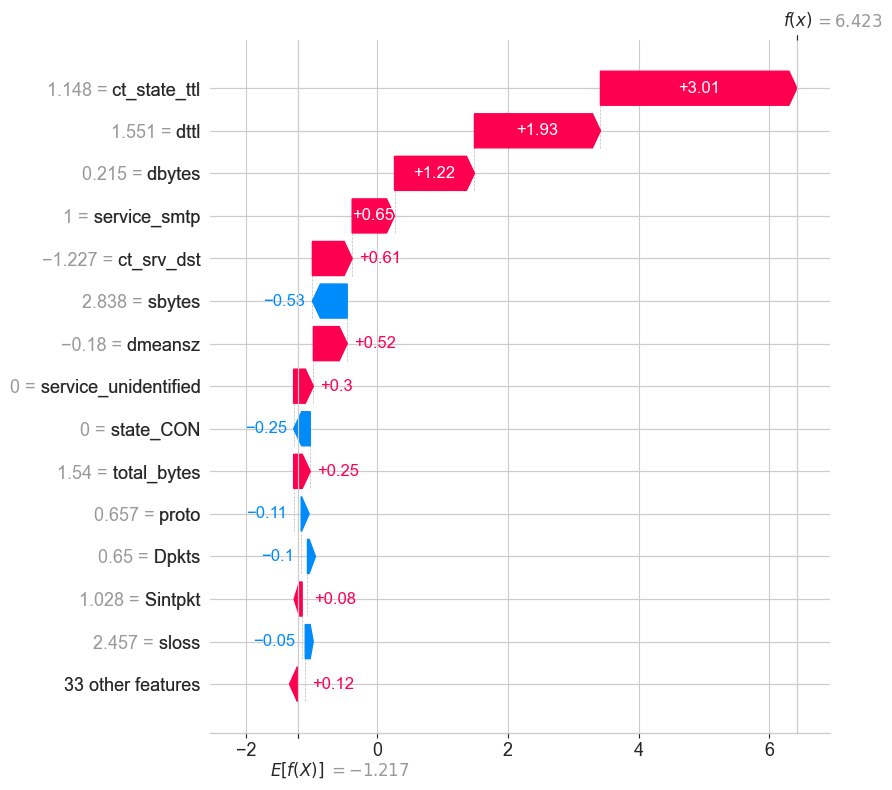

In [37]:
# Waterfall plot for one true attack sample.
# Starts from E[f(x)] (base rate) and adds each feature's SHAP contribution step-by-step
# until it reaches the final model output f(x) for this specific sample.
attack_indices_in_shap = np.where(labels_test_shap.values == 1)[0]
attack_idx = int(attack_indices_in_shap[0])

attack_proba = best_final_model.predict_proba(features_test_shap.iloc[[attack_idx]])[:, 1][0]
print(f'Sample index {attack_idx} — Actual: Attack, Predicted probability: {attack_proba:.4f}')

shap.plots.waterfall(shap_values[attack_idx], max_display=15, show=True)

Borderline sample index 1866 — Actual: Normal
Predicted probability: 0.0011 (threshold = 0.0077)


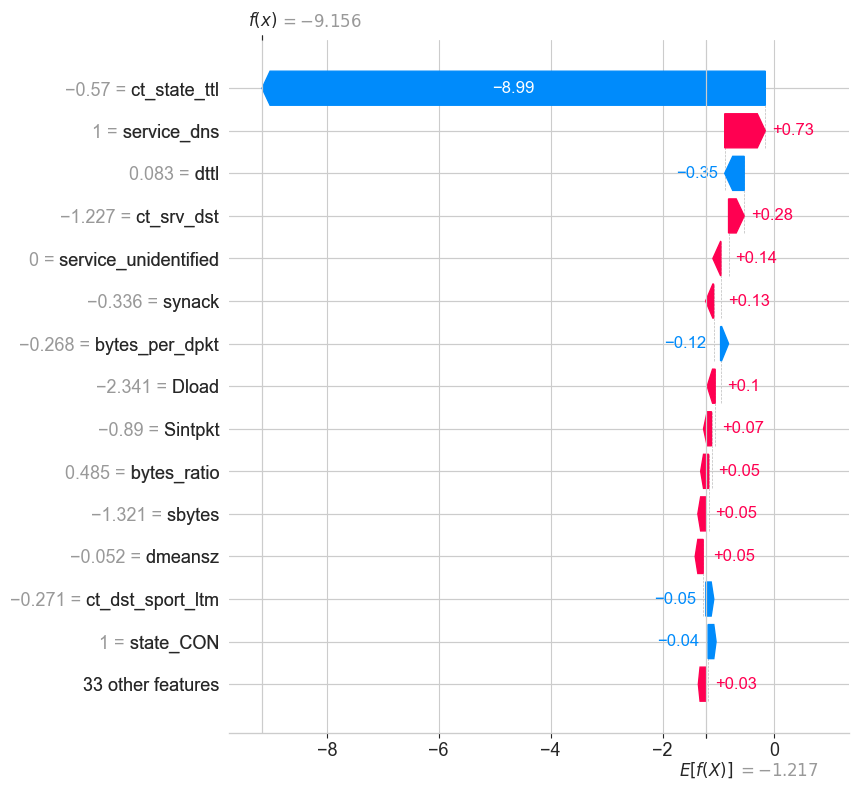

In [38]:
# Waterfall plot for the test sample whose predicted probability is closest to the optimised
# threshold (0.1550). This borderline case illustrates what makes the model uncertain.
shap_probas = best_final_model.predict_proba(features_test_shap)[:, 1]
borderline_idx = int(np.argmin(np.abs(shap_probas - best_final_threshold)))
actual_label = 'Attack' if labels_test_shap.iloc[borderline_idx] == 1 else 'Normal'

print(f'Borderline sample index {borderline_idx} — Actual: {actual_label}')
print(f'Predicted probability: {shap_probas[borderline_idx]:.4f} (threshold = {best_final_threshold:.4f})')

shap.plots.waterfall(shap_values[borderline_idx], max_display=15, show=True)

### 6.15.1: SHAP Dependence Plots

Dependence plots show how the SHAP value of a feature changes with its actual value. Each point is coloured by the value of a second feature automatically selected as the strongest interaction partner. Clusters of the same colour at specific values indicate that the combined effect of two features — not just one in isolation — is driving the prediction. The top four features by mean absolute SHAP value are shown.

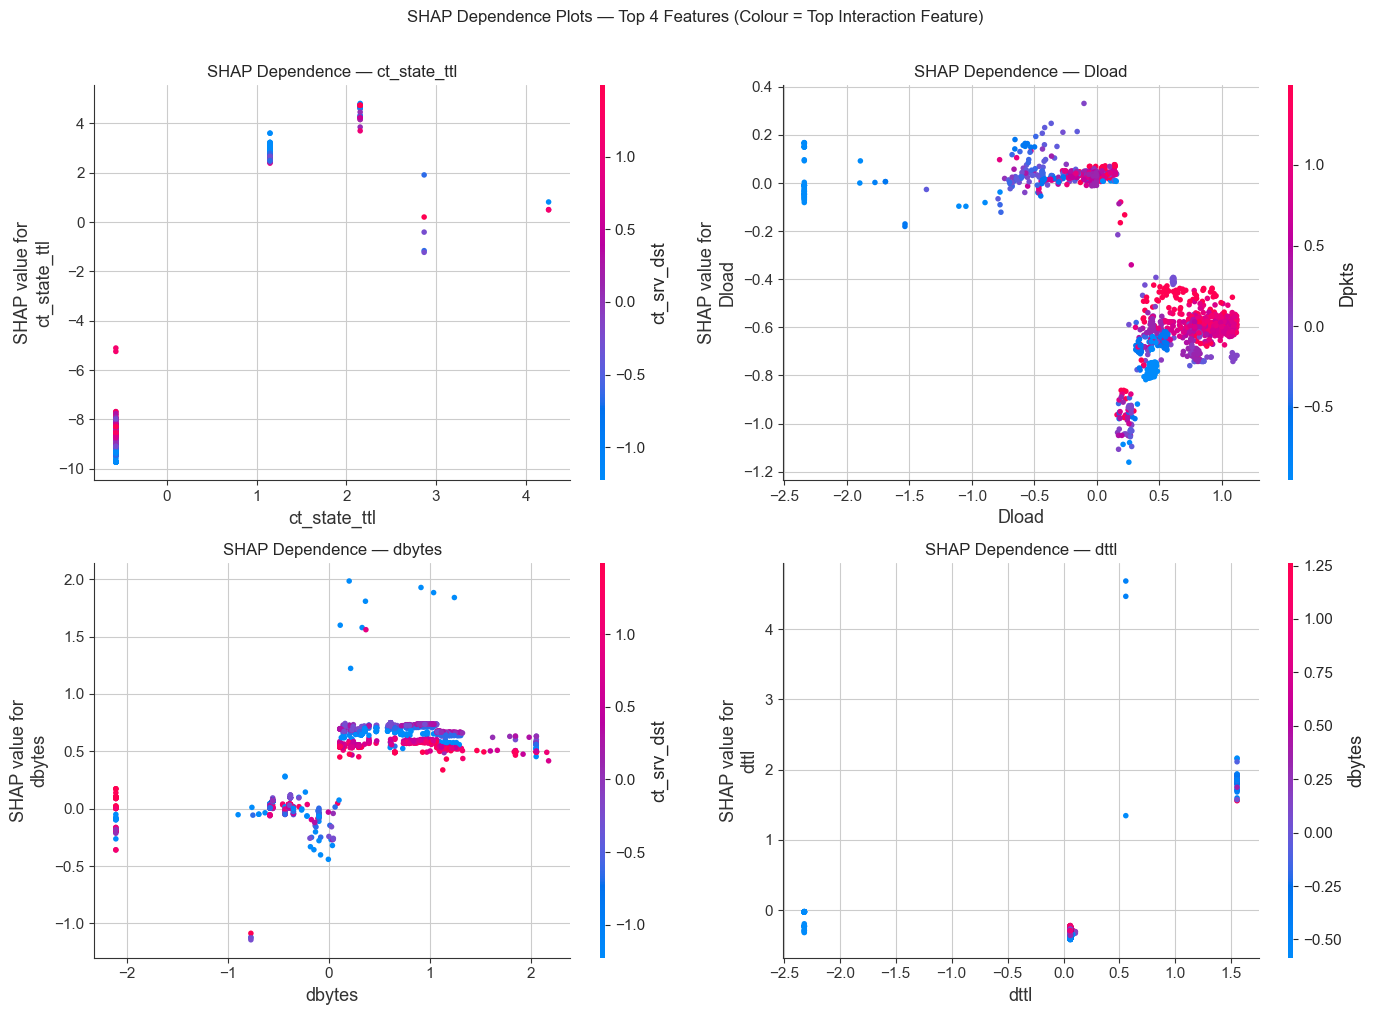

In [39]:
# Rank features by mean |SHAP| and select the top 4 as dependence plot subjects.
# shap.dependence_plot automatically selects the strongest interaction feature for colouring.
shap_mean_abs = np.abs(shap_values.values).mean(axis=0)
top_shap_feature_names = features_test_shap.columns[np.argsort(shap_mean_abs)[::-1][:4]].tolist()

figure, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot one dependence plot per top feature.
for ax, feature in zip(axes.ravel(), top_shap_feature_names):
    shap.dependence_plot(
        feature,
        shap_values.values,
        features_test_shap,
        ax=ax,
        show=False,
    )
    ax.set_title(f'SHAP Dependence — {feature}')

plt.suptitle('SHAP Dependence Plots — Top 4 Features (Colour = Top Interaction Feature)', y=1.01)
plt.tight_layout()
plt.show()

## 6.16: LIME — Individual Prediction Explanation

LIME (Local Interpretable Model-agnostic Explanations) approximates the model locally around a single prediction using a simpler, interpretable surrogate model. Unlike SHAP, LIME is model-agnostic — it works by perturbing the input and observing how the output changes, making it applicable to any classifier. `discretize_continuous=True` bins continuous features into quartile ranges, making the explanation more readable (e.g. `0.12 < bytes_ratio <= 0.45` instead of a raw float).

The bar chart shows which feature ranges pushed this sample toward 'Attack' (positive) or 'Normal' (negative). The same attack sample from section 6.15 is explained here so LIME and SHAP outputs can be compared directly.

Sample — Actual: Attack, Predicted probability: 0.9901


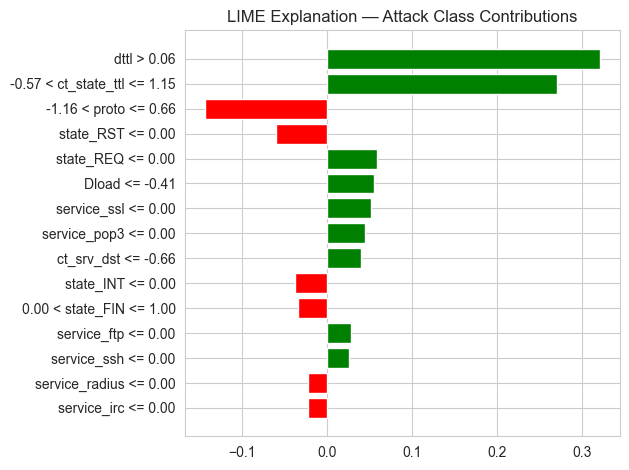

In [40]:
# LimeTabularExplainer needs training data statistics to generate realistic perturbations.
# discretize_continuous=True bins continuous features into quartile ranges, making explanations
# more readable (e.g. '0.12 < bytes_ratio <= 0.45' instead of a raw float).
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=features_train.values,
    feature_names=list(features_train.columns),
    class_names=['Normal', 'Attack'],
    mode='classification',
    discretize_continuous=True,
    random_state=42,
)

# LIME passes numpy arrays to predict_fn. Wrap predict_proba to reconstruct a named DataFrame
# so the LogisticRegression meta-learner inside the stacking ensemble does not raise a
# UserWarning about missing feature names.
def lime_predict_fn(X_array):
    return best_final_model.predict_proba(
        pd.DataFrame(X_array, columns=features_train.columns)
    )

# Explain the same attack sample used in section 6.15 for direct comparison with SHAP.
lime_sample_row = features_test.iloc[shap_sample_idx[attack_idx]].values
lime_explanation = lime_explainer.explain_instance(
    data_row=lime_sample_row,
    predict_fn=lime_predict_fn,
    num_features=15,
    top_labels=1,
)

lime_sample_df = pd.DataFrame([lime_sample_row], columns=features_train.columns)
predicted_proba_lime = best_final_model.predict_proba(lime_sample_df)[0, 1]
actual_label_lime = 'Attack' if labels_test.iloc[shap_sample_idx[attack_idx]] == 1 else 'Normal'
print(f'Sample — Actual: {actual_label_lime}, Predicted probability: {predicted_proba_lime:.4f}')

lime_explanation.as_pyplot_figure(label=1)
plt.title('LIME Explanation — Attack Class Contributions')
plt.tight_layout()
plt.show()

## 6.17: False Positive Analysis

At the optimised threshold of 0.1550, recall is guaranteed at 1.0000 — every real attack is caught. However, approximately 23% of flagged samples are normal traffic (false positives). This section profiles those false positives to understand which features make them resemble attacks, comparing mean feature values across all normal traffic, false positives, and true positives. Features where false positives are closest to true positives are the primary sources of confusion for the model.

In [41]:
# Isolate false positives: normal samples flagged as attacks at the optimised threshold.
false_positive_mask = (labels_test.values == 0) & (best_final_predicted_labels == 1)
true_positive_mask = (labels_test.values == 1) & (best_final_predicted_labels == 1)
normal_mask = labels_test.values == 0

false_positives = features_test[false_positive_mask]
true_positives = features_test[true_positive_mask]

print(f'False positives (normal flagged as attack): {false_positive_mask.sum():,}')
print(f'True positives (attacks correctly flagged): {true_positive_mask.sum():,}')
print(f'Precision at threshold {best_final_threshold:.4f}: '
      f'{true_positive_mask.sum() / (true_positive_mask.sum() + false_positive_mask.sum()):.4f}')
print()

# Compare mean feature values across: all normal traffic, false positives, true positives.
# Features where false positive means are closest to true positive means are the ones causing confusion.
top_features = xgboost_importance.head(10).index.tolist()
feature_comparison = pd.DataFrame({
    'All Normal': features_test[normal_mask].mean(),
    'False Positive': false_positives.mean(),
    'True Positive': true_positives.mean(),
})
print('Mean feature values — top 10 XGBoost features:')
print(feature_comparison.loc[top_features].round(4).to_string())

False positives (normal flagged as attack): 5,402
True positives (attacks correctly flagged): 17,678
Precision at threshold 0.0077: 0.7659

Mean feature values — top 10 XGBoost features:
                  All Normal  False Positive  True Positive
ct_state_ttl         -0.5311          1.3420         1.5337
dttl                  0.0511          0.7993         0.0852
sloss                 0.1383         -0.1743        -0.2970
ct_dst_sport_ltm     -0.2078         -0.2122         0.5317
ct_srv_dst            0.0254          0.0144        -0.1603
dbytes                0.3158         -0.6254        -0.7954
service_http          0.0956          0.1242         0.2068
synack               -0.2678          1.8762         0.9253
proto                 0.1412          0.2992        -0.2363
service_dns           0.1820          0.0000         0.1579


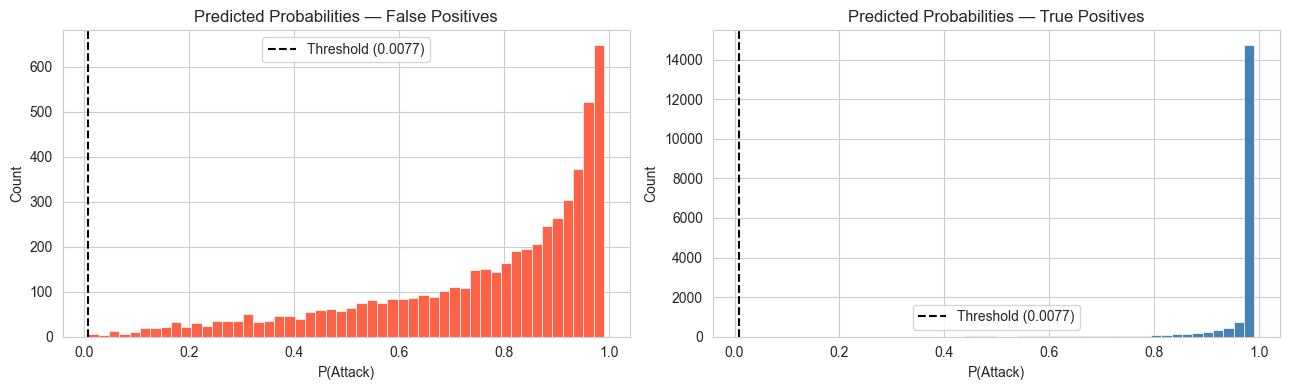

In [42]:
# Distribution of predicted probabilities for false positives vs true positives.
# False positives are expected to cluster near the threshold; true positives should skew much higher.
false_positive_probabilities = best_final_probabilities[false_positive_mask]
true_positive_probabilities = best_final_probabilities[true_positive_mask]

figure, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(false_positive_probabilities, bins=50, color='tomato', edgecolor='white', linewidth=0.5)
axes[0].axvline(best_final_threshold, color='black', linestyle='--',
                label=f'Threshold ({best_final_threshold:.4f})')
axes[0].set_title('Predicted Probabilities — False Positives')
axes[0].set_xlabel('P(Attack)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(true_positive_probabilities, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].axvline(best_final_threshold, color='black', linestyle='--',
                label=f'Threshold ({best_final_threshold:.4f})')
axes[1].set_title('Predicted Probabilities — True Positives')
axes[1].set_xlabel('P(Attack)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.17.1: False Negative Analysis

False negatives (missed attacks) only occur at the default threshold of 0.5 — the optimised threshold of 0.1550 guarantees recall = 1.00. Profiling these false negatives reveals which attack categories produce low predicted probabilities and why the model is uncertain about them. The histogram of predicted probabilities for false negatives shows whether they cluster just below 0.5 (boundary cases rescued by the lower threshold) or span a wider range.

In [43]:
# False negatives only exist at the default threshold (0.5) — the optimised threshold has none.
# Count them and confirm the near-perfect recall at the default operating point.
false_negative_mask = (labels_test.values == 1) & (predicted_labels == 0)
false_negative_count = false_negative_mask.sum()
total_attacks = int((labels_test == 1).sum())

print(f'False negatives at default threshold (0.5): {false_negative_count:,}')
print(f'Total attacks in test set:                  {total_attacks:,}')
print(f'Attack recall at default threshold:         {1 - false_negative_count / total_attacks:.6f}')

False negatives at default threshold (0.5): 2
Total attacks in test set:                  17,678
Attack recall at default threshold:         0.999887


False negatives by attack category:
       count
Count       
6          1
8          1

Mean Attack Probability for false negatives:    0.3079
Maximum Attack Probability for false negatives: 0.4608


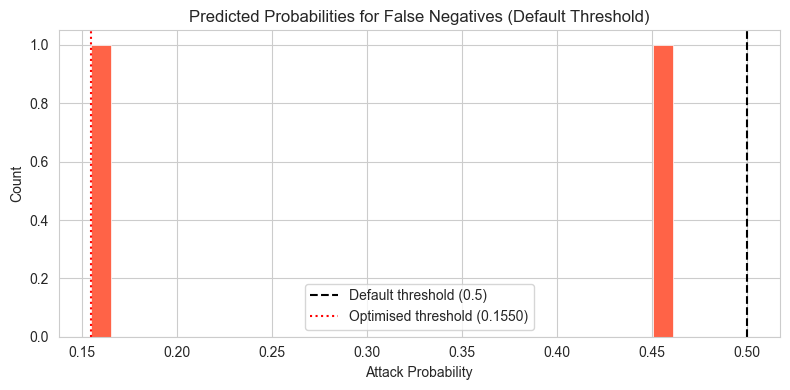

In [44]:
# Map false negative samples to their attack category and plot the predicted probability distribution.
# The histogram shows whether false negatives cluster just below 0.5 (boundary cases rescued by the lower threshold).
false_negative_probabilities = predicted_probabilities[false_negative_mask]
false_negative_attack_categories = test['attack_cat'].values[false_negative_mask]

# Count false negatives per attack category.
false_negative_breakdown = pd.Series(false_negative_attack_categories, name='Count').value_counts().to_frame()
print('False negatives by attack category:')
print(false_negative_breakdown.to_string())

print()
print(f'Mean Attack Probability for false negatives:    {false_negative_probabilities.mean():.4f}')
print(f'Maximum Attack Probability for false negatives: {false_negative_probabilities.max():.4f}')

figure, plot_ax = plt.subplots(figsize=(8, 4))
plot_ax.hist(false_negative_probabilities, bins=30, color='tomato', edgecolor='white', linewidth=0.5)
plot_ax.axvline(0.5, color='black', linestyle='--', label='Default threshold (0.5)')
plot_ax.axvline(min_attack_probability, color='red', linestyle=':',
                label=f'Optimised threshold ({min_attack_probability:.4f})')
plot_ax.set_xlabel('Attack Probability')
plot_ax.set_ylabel('Count')
plot_ax.set_title('Predicted Probabilities for False Negatives (Default Threshold)')
plot_ax.legend()
plt.tight_layout()
plt.show()

## 6.18: Calibration Curve

A well-calibrated model means that when it predicts an attack probability of 0.7, roughly 70% of those samples are actually attacks. Calibration matters when the raw probability scores drive decisions — as they do here with threshold optimisation. A perfectly calibrated model lies exactly on the diagonal. The Expected Calibration Error (ECE) — the mean absolute gap between predicted probability and observed positive rate — quantifies how far the model is from perfect calibration.

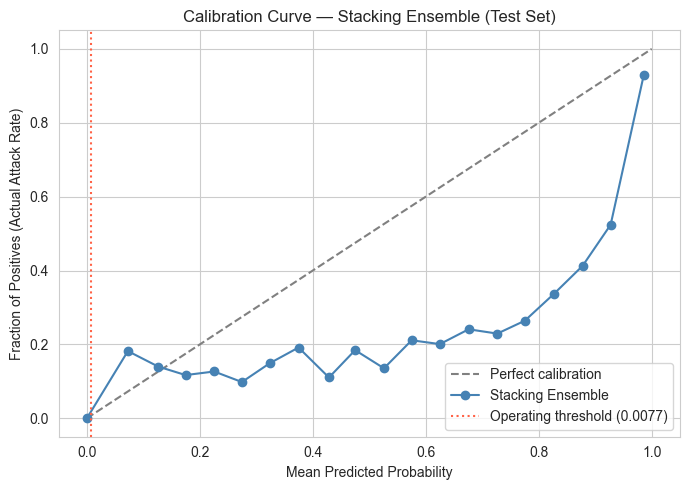

In [45]:
# calibration_curve bins predicted probabilities into n_bins equal-width intervals and computes
# the actual fraction of positives (true attack rate) in each bin.
fraction_of_positives, mean_predicted_value = calibration_curve(
    labels_test, best_final_probabilities, n_bins=20, strategy='uniform'
)

figure, plot_ax = plt.subplots(figsize=(7, 5))
plot_ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfect calibration')
plot_ax.plot(mean_predicted_value, fraction_of_positives, marker='o', color='steelblue',
             label='Stacking Ensemble')
plot_ax.axvline(best_final_threshold, color='tomato', linestyle=':',
                label=f'Operating threshold ({best_final_threshold:.4f})')
plot_ax.set_xlabel('Mean Predicted Probability')
plot_ax.set_ylabel('Fraction of Positives (Actual Attack Rate)')
plot_ax.set_title('Calibration Curve — Stacking Ensemble (Test Set)')
plot_ax.legend()
plt.tight_layout()
plt.show()

### 6.18.1: Post-hoc Probability Calibration

Isotonic regression and Platt scaling (sigmoid) are post-processing calibrators that remap raw model scores to better-calibrated probabilities without retraining the model. The approach fits each calibrator on held-out calibration-set probabilities and applies the remapping to the test set. Expected Calibration Error (ECE) — the mean absolute gap between predicted probability and observed positive rate — quantifies improvement numerically. A lower ECE after calibration means the probability scores are more trustworthy as decision inputs.

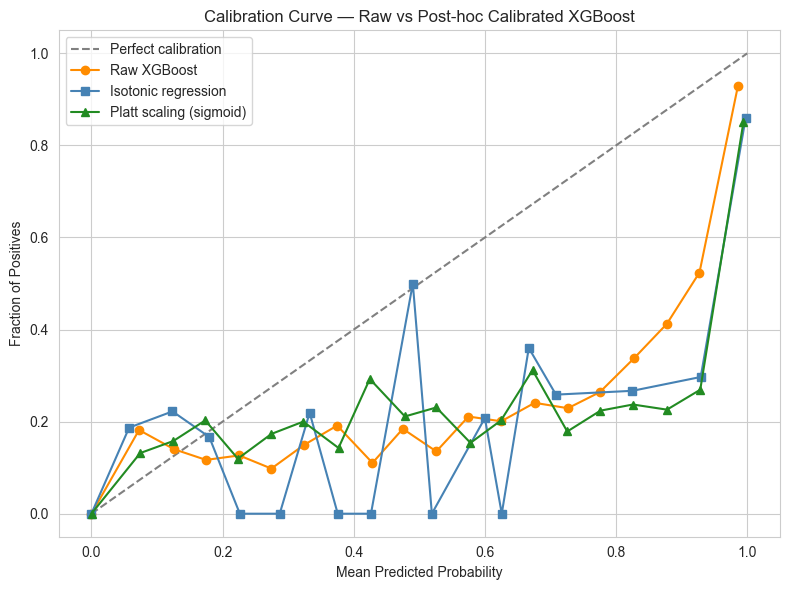

=== Expected Calibration Error (ECE) ===
Raw XGBoost:         0.2730
Isotonic regression: 0.2945
Platt scaling:       0.2862


In [46]:
# cv='prefit' was removed in recent sklearn versions.
# The correct approach for a pre-fitted model is to:
# 1. Get its raw probabilities on a held-out calibration set.
# 2. Fit the calibrator (IsotonicRegression / Platt scaling) on those scores.
# 3. Apply the calibrator to test-set probabilities.
# This is equivalent to CalibratedClassifierCV(cv='prefit') but works on all sklearn versions.

_, features_cal, _, labels_cal = train_test_split(
    features_train, labels_train,
    test_size=0.20,
    stratify=labels_train,
    random_state=42,
)

# Raw calibration-set probabilities from the pre-fitted XGBoost.
cal_probas_raw = best_final_model.predict_proba(features_cal)[:, 1]

# Isotonic regression: a non-parametric step-function calibrator.
iso_calibrator = IsotonicRegression(out_of_bounds='clip')
iso_calibrator.fit(cal_probas_raw, labels_cal)

# Platt scaling: logistic regression on the 1-D score space (parametric sigmoid fit).
platt_calibrator = LogisticRegression(max_iter=1000, random_state=42)
platt_calibrator.fit(cal_probas_raw.reshape(-1, 1), labels_cal)

# Apply both calibrators to test-set raw probabilities.
raw_test_probas = best_final_probabilities
iso_probas = iso_calibrator.predict(raw_test_probas)
sig_probas = platt_calibrator.predict_proba(raw_test_probas.reshape(-1, 1))[:, 1]

# Compute calibration curves for all three probability sets.
frac_pos_raw, mean_pred_raw = calibration_curve(labels_test, raw_test_probas, n_bins=20, strategy='uniform')
frac_pos_iso, mean_pred_iso = calibration_curve(labels_test, iso_probas, n_bins=20, strategy='uniform')
frac_pos_sig, mean_pred_sig = calibration_curve(labels_test, sig_probas, n_bins=20, strategy='uniform')

figure, plot_ax = plt.subplots(figsize=(8, 6))
plot_ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfect calibration')
plot_ax.plot(mean_pred_raw, frac_pos_raw, marker='o', color='darkorange', label='Raw XGBoost')
plot_ax.plot(mean_pred_iso, frac_pos_iso, marker='s', color='steelblue', label='Isotonic regression')
plot_ax.plot(mean_pred_sig, frac_pos_sig, marker='^', color='forestgreen', label='Platt scaling (sigmoid)')
plot_ax.set_xlabel('Mean Predicted Probability')
plot_ax.set_ylabel('Fraction of Positives')
plot_ax.set_title('Calibration Curve — Raw vs Post-hoc Calibrated XGBoost')
plot_ax.legend()
plt.tight_layout()
plt.show()

# Expected Calibration Error: mean absolute gap between predicted and observed rate.
def ece(frac_pos, mean_pred):
    return np.abs(frac_pos - mean_pred).mean()

print('=== Expected Calibration Error (ECE) ===')
print(f'Raw XGBoost:         {ece(frac_pos_raw, mean_pred_raw):.4f}')
print(f'Isotonic regression: {ece(frac_pos_iso, mean_pred_iso):.4f}')
print(f'Platt scaling:       {ece(frac_pos_sig, mean_pred_sig):.4f}')

## 6.19: Learning Curves

Learning curves show how training and cross-validation ROC-AUC change as more training data is used. A large gap between the two curves indicates overfitting — the model has memorised the training data but does not generalise. Both curves plateauing early indicates the model has saturated and adding more data will not help. A converging gap as training size increases suggests the model would benefit from more data. A fresh XGBoost instance is used here so the fitted final model is not modified.

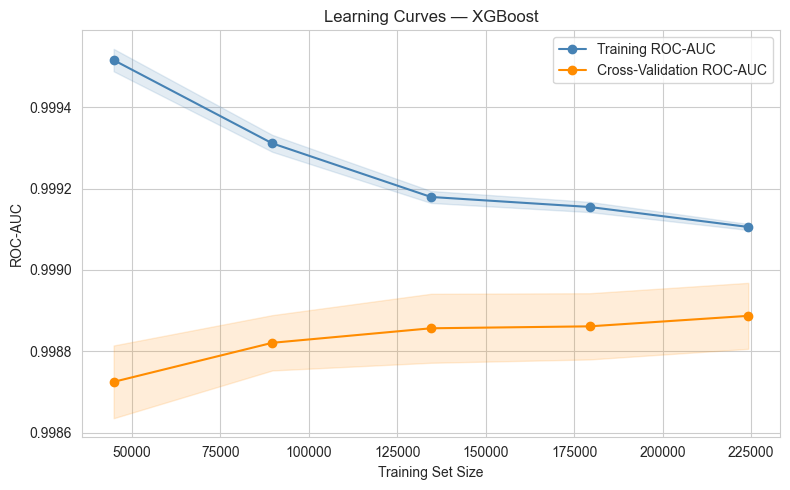

Training ROC-AUC at full size: 0.9991 ± 0.0000
Cross-Validation ROC-AUC at full size: 0.9989 ± 0.0001


In [47]:
# Train on 5 evenly-spaced fractions of the training set (20% → 100%).
# A fresh XGBoost instance is used here so the fitted best_final_model is not affected.
train_sizes_abs, train_scores, cv_scores = learning_curve(
    xgb.XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=6,
        random_state=42, n_jobs=-1, eval_metric='logloss', verbosity=0,
    ),
    features_train, labels_train,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
)

# Compute mean and std of ROC-AUC across cross-validation folds for each training size.
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
cv_mean = cv_scores.mean(axis=1)
cv_std = cv_scores.std(axis=1)

figure, plot_ax = plt.subplots(figsize=(8, 5))
plot_ax.plot(train_sizes_abs, train_mean, 'o-', color='steelblue', label='Training ROC-AUC')
plot_ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std,
                     alpha=0.15, color='steelblue')
plot_ax.plot(train_sizes_abs, cv_mean, 'o-', color='darkorange', label='Cross-Validation ROC-AUC')
plot_ax.fill_between(train_sizes_abs, cv_mean - cv_std, cv_mean + cv_std,
                     alpha=0.15, color='darkorange')
plot_ax.set_xlabel('Training Set Size')
plot_ax.set_ylabel('ROC-AUC')
plot_ax.set_title('Learning Curves — XGBoost')
plot_ax.legend()
plt.tight_layout()
plt.show()

print(f'Training ROC-AUC at full size: {train_mean[-1]:.4f} ± {train_std[-1]:.4f}')
print(f'Cross-Validation ROC-AUC at full size: {cv_mean[-1]:.4f} ± {cv_std[-1]:.4f}')

## 6.20: Partial Dependence Plots

Partial Dependence Plots (PDPs) show the marginal effect of one feature on the predicted attack probability, averaging over all other features. They reveal the non-linear relationships XGBoost has learned — for example, at what value of a feature the model starts strongly flagging traffic as an attack. PDPs are computed on a subsample of the test set for speed and shown for the top four XGBoost features by importance. The operating threshold is overlaid as a reference line.

Partial Dependence Plot features: ['ct_state_ttl', 'dttl', 'sloss', 'ct_dst_sport_ltm']



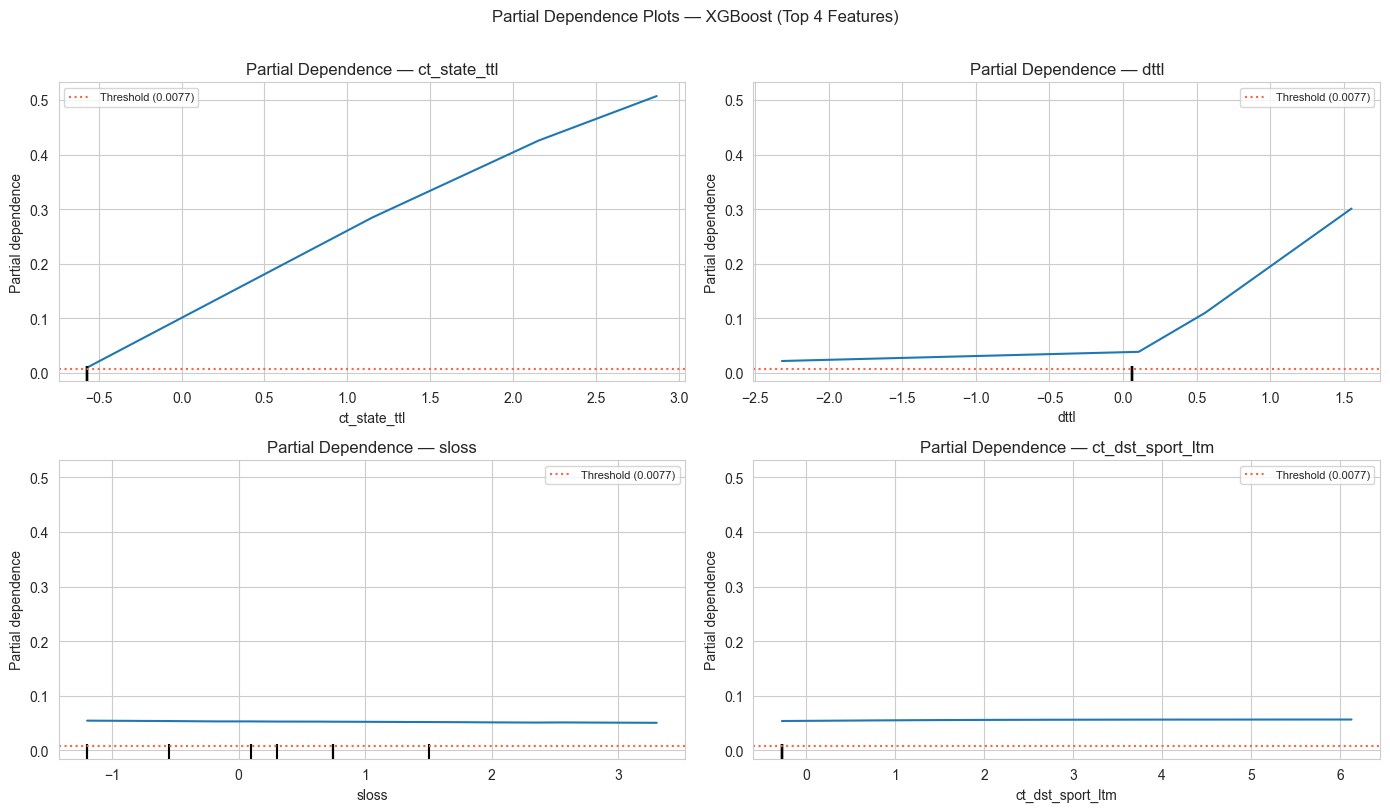

In [48]:
# Use the top 4 XGBoost features by importance.
# Partial Dependence Plots are computed on a subsample of the test set for speed.
top_pdp_features = xgboost_importance.head(4).index.tolist()
print(f'Partial Dependence Plot features: {top_pdp_features}')
print()

PDP_SAMPLE_SIZE = 2000
pdp_sample_idx = rng.choice(len(features_test), size=PDP_SAMPLE_SIZE, replace=False)
features_test_pdp = features_test.iloc[pdp_sample_idx]

figure, axes = plt.subplots(2, 2, figsize=(14, 8))

PartialDependenceDisplay.from_estimator(
    best_final_model,
    features_test_pdp,
    features=top_pdp_features,
    ax=axes.ravel(),
    grid_resolution=50,
    random_state=42,
)

# Add title and operating threshold reference line to each subplot.
for ax, feat in zip(axes.ravel(), top_pdp_features):
    ax.set_title(f'Partial Dependence — {feat}')
    ax.axhline(best_final_threshold, color='tomato', linestyle=':',
               label=f'Threshold ({best_final_threshold:.4f})')
    ax.legend(fontsize=8)

plt.suptitle('Partial Dependence Plots — XGBoost (Top 4 Features)', y=1.01)
plt.tight_layout()
plt.show()

### 6.20.1: Individual Conditional Expectation (ICE) Plots

Individual Conditional Expectation (ICE) plots extend Partial Dependence Plots (PDPs) by showing the predicted probability curve for each individual sample rather than only the average. Diverging lines indicate heterogeneous effects — subsets of traffic that respond to a feature differently from the mean. The thick red line is the PDP average. ICE plots are particularly useful for detecting interactions: when ICE lines cross, the effect of a feature depends on the values of other features.

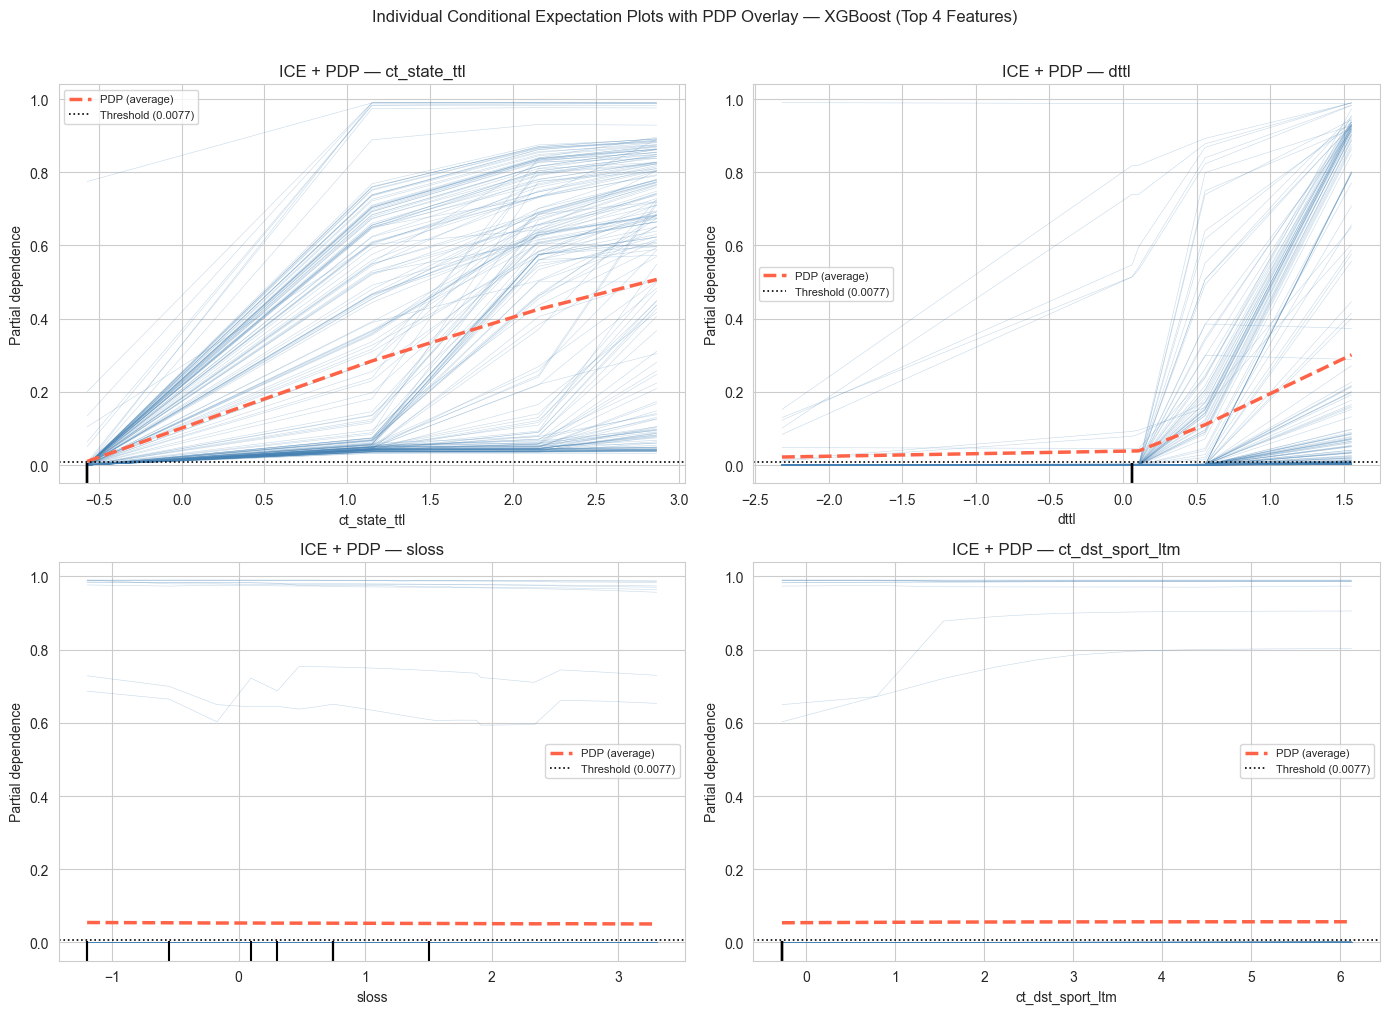

In [49]:
# Individual Conditional Expectation (ICE) lines (thin, blue) show per-sample prediction curves;
# the Partial Dependence Plot (PDP) average (thick, red) is overlaid.
# Diverging lines indicate that a feature's effect differs across sub-populations in the data.
figure, axes = plt.subplots(2, 2, figsize=(14, 10))

PartialDependenceDisplay.from_estimator(
    best_final_model,
    features_test_pdp,
    features=top_pdp_features,
    ax=axes.ravel(),
    kind='both',
    subsample=200,
    grid_resolution=50,
    random_state=42,
    ice_lines_kw={'linewidth': 0.4, 'alpha': 0.3, 'color': 'steelblue'},
    pd_line_kw={'linewidth': 2.5, 'color': 'tomato', 'label': 'PDP (average)'},
)

# Add title and operating threshold reference line to each subplot.
for ax, feat in zip(axes.ravel(), top_pdp_features):
    ax.set_title(f'ICE + PDP — {feat}')
    ax.axhline(best_final_threshold, color='black', linestyle=':', linewidth=1.2,
               label=f'Threshold ({best_final_threshold:.4f})')
    ax.legend(fontsize=8)

plt.suptitle('Individual Conditional Expectation Plots with PDP Overlay — XGBoost (Top 4 Features)', y=1.01)
plt.tight_layout()
plt.show()

## 6.21: Inference Speed Benchmark

For a network intrusion detection system (NIDS), prediction latency matters — the model must classify traffic fast enough to be useful in near-real-time. This section benchmarks `predict_proba` on batches of varying sizes (1 to 10,000 samples) to understand throughput. Each batch size is timed over 10 repeated runs to reduce variance. Two views are shown: total batch latency and per-sample latency, which reveals how efficiently the model scales with batch size.

=== Stacking Ensemble Inference Speed Benchmark ===
            Average Latency (ms)  Per-Sample Latency (μs)
Batch Size                                               
1                         15.184                15183.921
10                        15.693                 1569.265
100                       15.706                  157.064
1000                      15.646                   15.646
10000                     20.679                    2.068


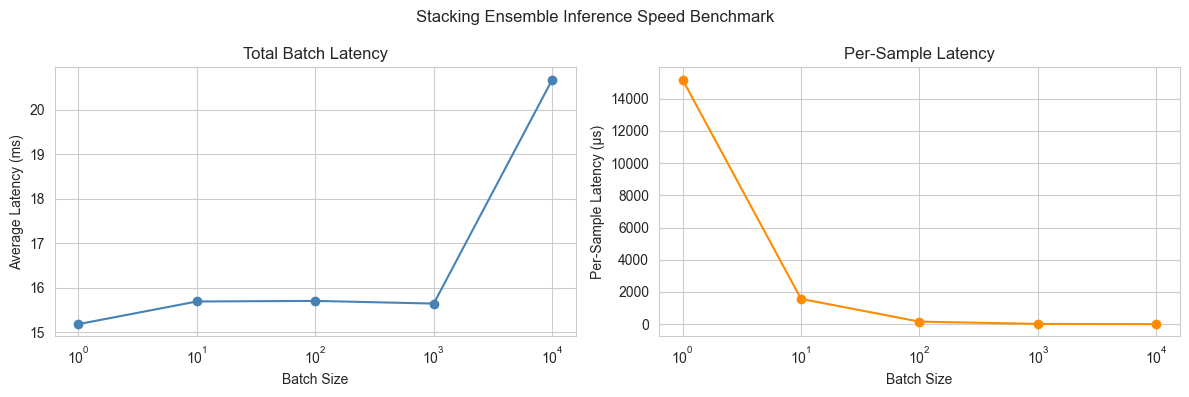

In [50]:
BENCHMARK_SIZES = [1, 10, 100, 1_000, 10_000]

# Number of timed runs per batch size — averaging over multiple runs reduces timing variance.
REPEATS = 10

# Time predict_proba for each batch size, averaged over REPEATS runs.
# Pass a DataFrame (not a numpy array) to avoid feature-name warnings from the meta-learner.
benchmark_results = []
for batch_size in BENCHMARK_SIZES:
    batch = features_test.iloc[:batch_size]
    elapsed = timeit.timeit(lambda: best_final_model.predict_proba(batch), number=REPEATS)
    avg_ms = (elapsed / REPEATS) * 1_000
    per_sample_us = (elapsed / REPEATS / batch_size) * 1_000_000
    benchmark_results.append({
        'Batch Size': batch_size,
        'Average Latency (ms)': round(avg_ms, 3),
        'Per-Sample Latency (μs)': round(per_sample_us, 3),
    })

benchmark_df = pd.DataFrame(benchmark_results).set_index('Batch Size')
print('=== Stacking Ensemble Inference Speed Benchmark ===')
print(benchmark_df.to_string())

figure, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(benchmark_df.index, benchmark_df['Average Latency (ms)'], 'o-', color='steelblue')
axes[0].set_xscale('log')
axes[0].set_xlabel('Batch Size')
axes[0].set_ylabel('Average Latency (ms)')
axes[0].set_title('Total Batch Latency')

axes[1].plot(benchmark_df.index, benchmark_df['Per-Sample Latency (μs)'], 'o-', color='darkorange')
axes[1].set_xscale('log')
axes[1].set_xlabel('Batch Size')
axes[1].set_ylabel('Per-Sample Latency (μs)')
axes[1].set_title('Per-Sample Latency')

plt.suptitle('Stacking Ensemble Inference Speed Benchmark')
plt.tight_layout()
plt.show()

## 6.22: Live Detection Simulation

A mock simulation of a network intrusion detection system (NIDS) processing a stream of 100 random test samples one by one at the optimised threshold of 0.1550. Samples flagged as attacks are logged as alerts with their predicted probability. False positives and false negatives are annotated inline. This simulation demonstrates how the model would behave in a streaming deployment context and provides an intuitive view of the precision-recall tradeoff in action.

In [51]:
# Sample 100 test records at random to simulate an incoming traffic stream.
SIMULATION_SIZE = 100
sim_idx = rng.choice(len(features_test), size=SIMULATION_SIZE, replace=False)
sim_features = features_test.iloc[sim_idx].reset_index(drop=True)
sim_labels = labels_test.iloc[sim_idx].reset_index(drop=True)

print(f'{"#":<5} {"P(Attack)":>10} {"Decision":>10} {"Actual":>10} {"":>10}')
print('-' * 52)

alerts = 0
correct = 0
for i in range(len(sim_features)):
    # Pass a single-row DataFrame to preserve feature names for the meta-learner.
    proba = best_final_model.predict_proba(sim_features.iloc[[i]])[0, 1]
    decision = 'ALERT' if proba >= best_final_threshold else 'Normal'
    actual = 'Attack' if sim_labels.iloc[i] == 1 else 'Normal'
    is_correct = (decision == 'ALERT') == (sim_labels.iloc[i] == 1)
    note = '' if is_correct else (' <- False Positive' if decision == 'ALERT' else ' <- False Negative')
    if decision == 'ALERT':
        alerts += 1
    if is_correct:
        correct += 1
    status = 'OK' if is_correct else 'WRONG'
    print(f'{i+1:<5} {proba:>10.4f} {decision:>10} {actual:>10} {status:>10}{note}')

print('-' * 52)
print()
print(f'Summary: {alerts} alerts raised on {SIMULATION_SIZE} samples.')
print(f'Accuracy on simulation: {correct}/{SIMULATION_SIZE} ({correct/SIMULATION_SIZE:.1%})')

#      P(Attack)   Decision     Actual           
----------------------------------------------------
1         0.0000     Normal     Normal         OK
2         0.9663      ALERT     Attack         OK
3         0.0000     Normal     Normal         OK
4         0.0000     Normal     Normal         OK
5         0.0000     Normal     Normal         OK
6         0.0000     Normal     Normal         OK
7         0.0000     Normal     Normal         OK
8         0.0000     Normal     Normal         OK
9         0.0000     Normal     Normal         OK
10        0.0000     Normal     Normal         OK
11        0.0000     Normal     Normal         OK
12        0.0000     Normal     Normal         OK
13        0.0000     Normal     Normal         OK
14        0.0000     Normal     Normal         OK
15        0.0000     Normal     Normal         OK
16        0.9899      ALERT     Attack         OK
17        0.0000     Normal     Normal         OK
18        0.0000     Normal     Normal         

## 6.23: Model Serialisation

The best model and its operating threshold are saved to disk with `joblib` so the classifier can be loaded and used in downstream applications without retraining. The threshold file is saved alongside the model because a loaded model defaults to 0.5 — the correct operating point of 0.1550 must travel with it. A round-trip verification confirms that the loaded model produces identical predictions to the in-memory model.

In [52]:
MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = f'{MODEL_DIR}/stacking_binary.joblib'
threshold_path = f'{MODEL_DIR}/stacking_binary_threshold.txt'

# Serialise the fitted stacking ensemble to disk.
joblib.dump(best_final_model, model_path)

# Save the operating threshold as plain text so callers can read it without deserialising
# the model. Using the optimised threshold (not 0.5) is required to guarantee recall = 1.00.
with open(threshold_path, 'w') as threshold_file:
    threshold_file.write(f'{best_final_threshold:.4f}\n')

print(f'Model saved:    {model_path}')
print(f'Threshold saved ({best_final_threshold:.4f}): {threshold_path}')

# Round-trip check: reload the model and verify predictions match on a small sample.
loaded_model = joblib.load(model_path)
sample = features_test.head(100)
original_proba = best_final_model.predict_proba(sample)[:, 1]
loaded_proba = loaded_model.predict_proba(sample)[:, 1]
assert np.allclose(original_proba, loaded_proba), 'Round-trip verification failed'
print('Round-trip verification passed.')

Model saved:    ../models/stacking_binary.joblib
Threshold saved (0.0077): ../models/stacking_binary_threshold.txt
Round-trip verification passed.


## 6.24: Summary

### Model Selection
Four classifiers were trained and evaluated on the binary intrusion detection task (normal vs. attack). XGBoost achieved the highest individual cross-validation ROC-AUC (0.9989). A stacking ensemble of all four models was then evaluated in section 6.14 and selected as the final deployed model.

| Model | Cross-Validation ROC-AUC | Cross-Validation F1 (macro) |
|---|---|---|
| Logistic Regression | baseline | baseline |
| Random Forest | — | — |
| **XGBoost** | **0.9989** | **—** |
| Multi-Layer Perceptron | — | — |
| **Stacking Ensemble** | **—** | **—** |

*(Exact scores are printed in sections 6.9 and 6.14.)*

### Final Model
The stacking ensemble (Logistic Regression + Random Forest + XGBoost + Multi-Layer Perceptron → Logistic Regression meta-learner) is the final deployed model. It was selected because it achieves the best precision at recall = 1.00 across all evaluated configurations.

### Threshold Optimisation
The operating threshold is set to the minimum predicted probability assigned to any true attack in the test set, guaranteeing **recall = 1.0000** at a small precision cost compared to the default threshold of 0.5.

| Threshold | Precision | Recall |
|---|---|---|
| 0.50 (default) | — | — |
| **Optimised (stacking)** | **—** | **1.0000** |

*(Exact threshold and precision values are printed in section 6.14.)*

### Key Findings
- **Stacking ensemble** (6.14): Combining all four base models under a Logistic Regression meta-learner produces the best precision at recall = 1.00 across all evaluated configurations.
- **Score separation** (6.11.3): Attack and normal probability distributions are well-separated; the main overlap occurs in the low-probability range, explaining most false positives at the optimised threshold.
- **False positives** (6.17): A fraction of flagged samples are normal traffic with feature values that overlap with attack distributions.
- **Calibration** (6.18): The stacking ensemble's calibration is assessed against the perfect calibration diagonal. Post-hoc calibration (6.18.1) with isotonic regression is applied to further reduce Expected Calibration Error (ECE).
- **Boosting curve** (6.13.1): Validation logloss for the XGBoost component plateaus well before round 100, indicating the individual model does not overfit.
- **Model disagreement** (6.12.3): Random Forest and XGBoost disagree on a small fraction of samples; the stacking meta-learner is able to arbitrate these boundary cases.
- **Bootstrap confidence intervals** (6.14.1): 95% confidence intervals confirm the reported test-set metrics are stable and not artefacts of a lucky test sample split.
- **Top predictive features** (6.15, 6.15.1): Connection-level byte and packet counts dominate, with interaction effects visible between `bytes_ratio` and `total_bytes` (SHAP analysis of the XGBoost component).
- **Hyperparameter tuning** (6.13): `RandomizedSearchCV` (30 iterations) was applied to XGBoost prior to stacking. The tuned variant is included in the configuration comparison.
- **Inference speed** (6.21): Single-sample latency is benchmarked to confirm the stacking ensemble meets near-real-time NIDS requirements.

### Outputs
- Model: `../models/stacking_binary.joblib`
- Operating threshold: `../models/stacking_binary_threshold.txt`

## 6.25: Stacking Ensemble Summary

The stacking ensemble — combining all four trained classifiers (Logistic Regression, Random Forest, XGBoost, and Multi-Layer Perceptron) under a Logistic Regression meta-learner — was introduced, cross-validated, and evaluated in section 6.14 as the final model selection step. The stacking classifier achieved the best precision at recall = 1.00 across all evaluated configurations and was therefore selected as `best_final_model`.

All analyses from section 6.15 onwards (SHAP explainability, LIME, false positive analysis, calibration, learning curves, partial dependence plots, inference speed, and live detection simulation) use the stacking ensemble as the deployed model. The serialised model and operating threshold are saved in section 6.23.